In [1]:
# Import all the necessary modules
import os
import sys
import os, sys
# from .../research/notebooks -> go up two levels to repo root
repo_root = os.path.abspath(os.path.join(os.getcwd(), "..", ".."))
if repo_root not in sys.path:
    sys.path.insert(0, repo_root)

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib as mpl
import matplotlib.ticker as mtick
from sklearn.decomposition import PCA
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn import linear_model
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score 
import pandas_datareader as pdr
import math
import datetime as dt
from datetime import datetime, timezone
import itertools
import ast
import yfinance as yf
import seaborn as sn
import yaml
import requests
from pathlib import Path
from IPython.display import display, HTML
from strategy_signal.trend_following_signal import (
    apply_jupyter_fullscreen_css, get_trend_donchian_signal_for_portfolio_with_rolling_r_sqr_vol_of_vol
)
from portfolio.strategy_performance import (calculate_sharpe_ratio, calculate_calmar_ratio, calculate_CAGR, calculate_risk_and_performance_metrics,
                                          calculate_compounded_cumulative_returns, estimate_fee_per_trade, rolling_sharpe_ratio)
from utils import coinbase_utils as cn
from portfolio import strategy_performance as perf
from sizing import position_sizing_binary_utils as size_bin
from sizing import position_sizing_continuous_utils as size_cont
from strategy_signal import trend_following_signal as tf
%matplotlib inline

In [2]:
import importlib
importlib.reload(cn)
importlib.reload(perf)
importlib.reload(tf)
importlib.reload(size_bin)
importlib.reload(size_cont)

<module 'sizing.position_sizing_continuous_utils' from '/Users/adheerchauhan/git/trend_following/sizing/position_sizing_continuous_utils.py'>

In [3]:
import warnings
warnings.filterwarnings('ignore')
pd.set_option('Display.max_rows', None)
pd.set_option('Display.max_columns',None)
apply_jupyter_fullscreen_css()

## Kraken Connection

### OHLC Data

In [9]:
import requests

def kraken_public_ohlc(pair: str, interval_min: int = 240, since: int | None = None):
    url = "https://api.kraken.com/0/public/OHLC"
    params = {"pair": pair, "interval": interval_min}
    if since is not None:
        params["since"] = since
    r = requests.get(url, params=params, timeout=30)
    r.raise_for_status()
    return r.json()

data = kraken_public_ohlc("BTC/USD", 240)
print(list(data.keys()))
print(data["error"])

['error', 'result']
[]


In [48]:
import pandas as pd

def kraken_ohlc_to_df(ohlc_json: dict) -> pd.DataFrame:
    """
    Convert Kraken OHLC JSON response (from /0/public/OHLC) into a pandas DataFrame.

    Output:
      - index: pandas datetime (UTC)
      - columns: open, high, low, close, vwap, volume, count
    """
    if ohlc_json.get("error"):
        raise RuntimeError(f"Kraken OHLC error: {ohlc_json['error']}")

    result = ohlc_json["result"]

    # Kraken uses a dynamic key for the pair in result, plus 'last'
    pair_key = next(k for k in result.keys() if k != "last")
    rows = result[pair_key]

    cols = ["time", "open", "high", "low", "close", "vwap", "volume", "count"]
    df = pd.DataFrame(rows, columns=cols)

    # Convert timestamp to pandas datetime (UTC)
    df["time"] = pd.to_datetime(df["time"], unit="s", utc=True)
    df = df.set_index("time").sort_index()

    # Cast numeric columns (Kraken returns strings for most fields)
    numeric_cols = ["open", "high", "low", "close", "vwap", "volume"]
    df[numeric_cols] = df[numeric_cols].astype(float)
    df["count"] = df["count"].astype(int)

    # Nice to keep the Kraken canonical pair key as metadata
    df.attrs["kraken_pair_key"] = pair_key
    df.attrs["last_cursor"] = result.get("last")

    return df


# Example usage:
data = kraken_public_ohlc("XBTUSD", 240)
df_btc = kraken_ohlc_to_df(data)
print(df_btc.head())
print(df_btc.tail())
print("pair_key:", df_btc.attrs["kraken_pair_key"], "last:", df_btc.attrs["last_cursor"])

                               open      high       low     close      vwap  \
time                                                                          
2025-10-27 12:00:00+00:00  115370.1  115370.1  114541.1  114940.0  114921.2   
2025-10-27 16:00:00+00:00  114940.1  115786.1  114791.9  114883.2  115389.8   
2025-10-27 20:00:00+00:00  114883.3  114883.3  113801.4  114153.0  114347.5   
2025-10-28 00:00:00+00:00  114153.1  114497.5  113593.2  113923.5  114014.3   
2025-10-28 04:00:00+00:00  113923.6  114273.4  113565.4  114273.4  113949.4   

                               volume  count  
time                                          
2025-10-27 12:00:00+00:00  219.494131   6778  
2025-10-27 16:00:00+00:00  195.420600   6668  
2025-10-27 20:00:00+00:00  181.587183   6250  
2025-10-28 00:00:00+00:00   87.820294   4902  
2025-10-28 04:00:00+00:00   59.914991   3416  
                              open     high      low    close     vwap  \
time                                       

In [117]:
df_btc.shape

(721, 7)

In [119]:
240*3

720

In [115]:
df_btc.head(20)

,open,high,low,close,vwap,volume,count
time,,,,,,,
2025-10-27 12:00:00+00:00,115370.1,115370.1,114541.1,114940.0,114921.2,219.494131,6778
2025-10-27 16:00:00+00:00,114940.1,115786.1,114791.9,114883.2,115389.8,195.420600,6668
2025-10-27 20:00:00+00:00,114883.3,114883.3,113801.4,114153.0,114347.5,181.587183,6250
2025-10-28 00:00:00+00:00,114153.1,114497.5,113593.2,113923.5,114014.3,87.820294,4902
2025-10-28 04:00:00+00:00,113923.6,114273.4,113565.4,114273.4,113949.4,59.914991,3416
2025-10-28 08:00:00+00:00,114273.4,114619.6,114135.0,114333.0,114476.9,105.508377,3317
2025-10-28 12:00:00+00:00,114333.0,116023.4,114160.0,114725.1,115065.7,424.472115,8141
2025-10-28 16:00:00+00:00,114725.1,115586.2,113597.0,113683.5,114622.7,356.721362,7934
2025-10-28 20:00:00+00:00,113683.6,113683.6,112278.2,112918.0,112875.6,394.934348,9871


In [52]:
df_btc.tail()

,open,high,low,close,vwap,volume,count
time,,,,,,,
2026-02-23 20:00:00+00:00,64282.8,64988.8,63888.0,64624.1,64583.5,737.762578,9957
2026-02-24 00:00:00+00:00,64624.1,64971.0,63123.6,63542.0,63749.3,833.687402,15705
2026-02-24 04:00:00+00:00,63542.1,63574.7,62679.6,63155.0,63105.6,398.168668,13162
2026-02-24 08:00:00+00:00,63160.0,63408.4,62929.5,63224.2,63195.6,194.928586,7085
2026-02-24 12:00:00+00:00,63224.2,63230.5,63118.7,63199.7,63154.3,13.960775,320


<Axes: xlabel='time'>

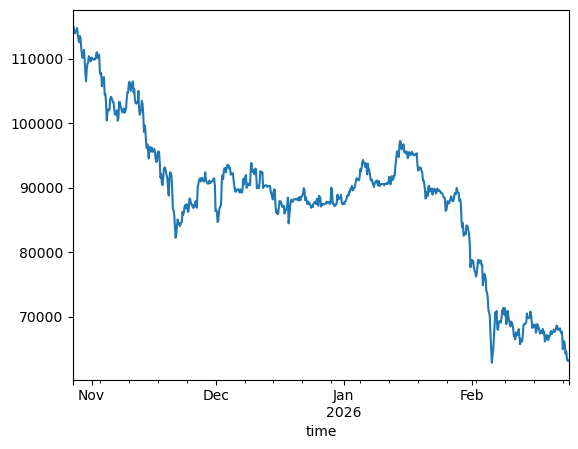

In [54]:
df_btc['close'].plot()

In [18]:
data = kraken_public_ohlc("XBTUSD", 240)

# Kraken uses a dynamic key for the pair inside "result"
print("Errors:", data["error"])
print("Result keys:", data["result"].keys())

# Pull out the OHLC array (first key that isn't 'last')
pair_key = next(k for k in data["result"].keys() if k != "last")
ohlc = data["result"][pair_key]

print("Pair key:", pair_key)
print("Num candles:", len(ohlc))
print("First candle:", ohlc[0])
print("Last candle:", ohlc[-1])

# 'last' is a server timestamp you can use for incremental pulling
print("Last cursor:", data["result"]["last"])

Errors: []
Result keys: dict_keys(['XXBTZUSD', 'last'])
Pair key: XXBTZUSD
Num candles: 721
First candle: [1761552000, '115562.9', '115562.9', '114846.5', '115370.1', '115297.2', '200.31445338', 4320]
Last candle: [1771920000, '63160.0', '63408.4', '62929.5', '63193.7', '63195.6', '194.63158398', 7003]
Last cursor: 1771905600


In [78]:
ohlc

[[1761552000,
  '115562.9',
  '115562.9',
  '114846.5',
  '115370.1',
  '115297.2',
  '200.31445338',
  4320],
 [1761566400,
  '115370.1',
  '115370.1',
  '114541.1',
  '114940.0',
  '114921.2',
  '219.49413055',
  6778],
 [1761580800,
  '114940.1',
  '115786.1',
  '114791.9',
  '114883.2',
  '115389.8',
  '195.42060049',
  6668],
 [1761595200,
  '114883.3',
  '114883.3',
  '113801.4',
  '114153.0',
  '114347.5',
  '181.58718335',
  6250],
 [1761609600,
  '114153.1',
  '114497.5',
  '113593.2',
  '113923.5',
  '114014.3',
  '87.82029355',
  4902],
 [1761624000,
  '113923.6',
  '114273.4',
  '113565.4',
  '114273.4',
  '113949.4',
  '59.91499133',
  3416],
 [1761638400,
  '114273.4',
  '114619.6',
  '114135.0',
  '114333.0',
  '114476.9',
  '105.50837703',
  3317],
 [1761652800,
  '114333.0',
  '116023.4',
  '114160.0',
  '114725.1',
  '115065.7',
  '424.47211467',
  8141],
 [1761667200,
  '114725.1',
  '115586.2',
  '113597.0',
  '113683.5',
  '114622.7',
  '356.72136187',
  7934],
 [1

In [74]:
data['result']#['XXBTZUSD']

{'BTC/USD': [[1761609600,
   '114153.1',
   '114497.5',
   '113593.2',
   '113923.5',
   '114014.3',
   '87.82029355',
   4902],
  [1761624000,
   '113923.6',
   '114273.4',
   '113565.4',
   '114273.4',
   '113949.4',
   '59.91499133',
   3416],
  [1761638400,
   '114273.4',
   '114619.6',
   '114135.0',
   '114333.0',
   '114476.9',
   '105.50837703',
   3317],
  [1761652800,
   '114333.0',
   '116023.4',
   '114160.0',
   '114725.1',
   '115065.7',
   '424.47211467',
   8141],
  [1761667200,
   '114725.1',
   '115586.2',
   '113597.0',
   '113683.5',
   '114622.7',
   '356.72136187',
   7934],
  [1761681600,
   '113683.6',
   '113683.6',
   '112278.2',
   '112918.0',
   '112875.6',
   '394.93434832',
   9871],
  [1761696000,
   '112918.0',
   '112918.0',
   '112118.5',
   '112550.0',
   '112507.1',
   '152.20341080',
   5050],
  [1761710400,
   '112550.0',
   '113511.0',
   '112549.9',
   '113511.0',
   '112964.6',
   '130.52635220',
   3637],
  [1761724800,
   '113511.0',
   '11360

## Private Requests using API Key & Secret

In [34]:
import time
import base64
import hashlib
import hmac
import urllib.parse
import requests

KRAKEN_API_URL = "https://api.kraken.com"
API_KEY = "LoBgNf94wTlWsuce8q36kfG9Ix1FKiksGMs/tiKgL6OH26kyYZ3heXgt"
API_SECRET = "gaoI8egmuFWfk5KqQ6xJewvgfhsh8/LaopxmPrHVV7ykoQh3L5TZ284Zn7Ooy98EOF7D6ultDprygWKu4TWjpg=="

def _kraken_api_sign(urlpath: str, data: dict, api_secret: str) -> str:
    """
    Creates API-Sign for Kraken private endpoints.
    api_secret is the *private key/secret* you saved (base64-encoded string).
    """
    postdata = urllib.parse.urlencode(data)
    encoded = (str(data["nonce"]) + postdata).encode()
    message = urlpath.encode() + hashlib.sha256(encoded).digest()
    mac = hmac.new(base64.b64decode(api_secret), message, hashlib.sha512)
    sigdigest = base64.b64encode(mac.digest())
    return sigdigest.decode()

def kraken_private_request(endpoint: str, api_key: str, api_secret: str, data: dict | None = None):
    """
    endpoint example: '/0/private/Balance'
    """
    if data is None:
        data = {}
    # Nonce must be strictly increasing; using ms timestamp is typical.
    data["nonce"] = int(time.time() * 1000)

    urlpath = endpoint
    url = KRAKEN_API_URL + urlpath

    headers = {
        "API-Key": api_key,
        "API-Sign": _kraken_api_sign(urlpath, data, api_secret),
    }

    r = requests.post(url, headers=headers, data=data, timeout=30)
    r.raise_for_status()
    j = r.json()
    if j.get("error"):
        raise RuntimeError(f"Kraken API error: {j['error']}")
    return j["result"]

# --- Examples ---

# 1) Balance
result = kraken_private_request("/0/private/Balance", API_KEY, API_SECRET)
print(result)

# 2) Open orders
result = kraken_private_request("/0/private/OpenOrders", API_KEY, API_SECRET, data={"trades": True})
print(result)

# 3) Closed orders (can be large; use 'start'/'end' as needed)
result = kraken_private_request("/0/private/ClosedOrders", API_KEY, API_SECRET, data={"trades": True})
print(result)

# 4) Ledger (fees, deposits/withdrawals; great for reconciliation)
result = kraken_private_request("/0/private/Ledgers", API_KEY, API_SECRET)
print(result)

{}
{'open': {}}
{'closed': {}, 'count': 0}
{'count': 0, 'ledger': {}}


## Get Tradable Pairs

In [123]:
import requests
import pandas as pd

def kraken_get_tradable_pairs() -> pd.DataFrame:
    url = "https://api.kraken.com/0/public/AssetPairs"
    r = requests.get(url, timeout=30)
    r.raise_for_status()
    j = r.json()
    if j.get("error"):
        raise RuntimeError(j["error"])

    pairs = j["result"]  # dict keyed by REST pair id like "XXBTZUSD"
    rows = []
    for rest_pair, meta in pairs.items():
        rows.append({
            "rest_pair": rest_pair,
            "altname": meta.get("altname"),     # e.g., "XBTUSD"
            "wsname": meta.get("wsname"),       # e.g., "XBT/USD" if available
            "base": meta.get("base"),
            "quote": meta.get("quote"),
            "status": meta.get("status"),       # "online", etc.
            "pair_decimals": meta.get("pair_decimals"),
            "lot_decimals": meta.get("lot_decimals"),
            "ordermin": meta.get("ordermin"),
            "costmin": meta.get("costmin"),
        })
    df = pd.DataFrame(rows)

    # Common filter: keep only currently tradable markets
    df = df[df["status"] == "online"].reset_index(drop=True)
    return df

df_pairs = kraken_get_tradable_pairs()
print(df_pairs.head())
print("Online pairs:", len(df_pairs))

  rest_pair   altname     wsname   base quote  status  pair_decimals  \
0     0GEUR     0GEUR     0G/EUR     0G  ZEUR  online              3   
1     0GUSD     0GUSD     0G/USD     0G  ZUSD  online              3   
2  1INCHEUR  1INCHEUR  1INCH/EUR  1INCH  ZEUR  online              4   
3  1INCHUSD  1INCHUSD  1INCH/USD  1INCH  ZUSD  online              4   
4     2ZEUR     2ZEUR     2Z/EUR     2Z  ZEUR  online              5   

   lot_decimals ordermin costmin  
0             5        2    0.45  
1             5        2     0.5  
2             8       11    0.45  
3             8       11     0.5  
4             5       10    0.45  
Online pairs: 1436


In [197]:
df_pairs[df_pairs['quote'] == 'ZUSD'].head(200)

,rest_pair,altname,wsname,base,quote,status
1,0GUSD,0GUSD,0G/USD,0G,ZUSD,online
3,1INCHUSD,1INCHUSD,1INCH/USD,1INCH,ZUSD,online
5,2ZUSD,2ZUSD,2Z/USD,2Z,ZUSD,online
9,AAVEUSD,AAVEUSD,AAVE/USD,AAVE,ZUSD,online
12,ABUSD,ABUSD,AB/USD,AB,ZUSD,online
14,ACAUSD,ACAUSD,ACA/USD,ACA,ZUSD,online
16,ACHUSD,ACHUSD,ACH/USD,ACH,ZUSD,online
18,ACTUSD,ACTUSD,ACT/USD,ACT,ZUSD,online
20,ACUUSD,ACUUSD,ACU/USD,ACU,ZUSD,online
22,ACXUSD,ACXUSD,ACX/USD,ACX,ZUSD,online


In [131]:
len(df_pairs[df_pairs['quote'] == 'ZUSD'].wsname.unique())

624

In [204]:
df_pairs.quote.unique()

array(['ZEUR', 'ZUSD', 'XETH', 'ZGBP', 'XXBT', 'ZAUD', 'USDC', 'USDT',
       'ZJPY', 'CHF', 'DAI', 'EURC', 'EUROP', 'FIDD', 'PYUSD', 'USD1',
       'ZCAD', 'SOL', 'AUSD', 'USDD', 'RLUSD', 'USDQ', 'USDR'],
      dtype=object)

## Create Tradable List of Coins

### Layer A Filter

In [206]:
## Removing Non-Crypto FX Pairs, Stablecoins, cash-like tokens and synthetic/wrapped/staked-derivative style instruments
remove_list = ['AUD/USD', 'EUR/USD', 'GBP/USD', 'USDC/USD', 'USDT/USD', 'DAI/USD', 'USDD/USD', 'USDE/USD', 'USDR/USD', 'USDS/USD', 'USD1/USD', 'USDG/USD', 'USDQ/USD',
               'USDUC/USD', 'PYUSD/USD', 'RLUSD/USD', 'AUSD/USD', 'AUDX/USD', 'EURC/USD', 'EUROP/USD', 'EURQ/USD', 'EURR/USD', 'TGBP/USD', 'BRL1/USD', 'CASH/USD',
               'WBTC/USD', 'TBTC/USD', 'PAXG/USD', 'XAUT/USD', 'CMETH/USD', 'METH/USD', 'LSETH/USD', 'JITOSOL/USD', 'LSSOL/USD', 'LSSOL/USD', 'MSOL/USD', 'MXNB/USD']
quote_list = ['ZUSD']

In [210]:
df_pairs_layer_a_filt_zusd = df_pairs[(~df_pairs.wsname.isin(remove_list)) & (df_pairs['quote'].isin(quote_list))].reset_index(drop=True)

In [212]:
print(df_pairs_layer_a_filt_zusd.shape)
df_pairs_layer_a_filt_zusd

(603, 6)


,rest_pair,altname,wsname,base,quote,status
0,0GUSD,0GUSD,0G/USD,0G,ZUSD,online
1,1INCHUSD,1INCHUSD,1INCH/USD,1INCH,ZUSD,online
2,2ZUSD,2ZUSD,2Z/USD,2Z,ZUSD,online
3,AAVEUSD,AAVEUSD,AAVE/USD,AAVE,ZUSD,online
4,ABUSD,ABUSD,AB/USD,AB,ZUSD,online
5,ACAUSD,ACAUSD,ACA/USD,ACA,ZUSD,online
6,ACHUSD,ACHUSD,ACH/USD,ACH,ZUSD,online
7,ACTUSD,ACTUSD,ACT/USD,ACT,ZUSD,online
8,ACUUSD,ACUUSD,ACU/USD,ACU,ZUSD,online
9,ACXUSD,ACXUSD,ACX/USD,ACX,ZUSD,online


### Layer B (Liquidity Metrics) & Layer C (Stability) Screen

In [405]:
"""
Kraken Universe Construction: Layer A + Layer B + Layer C
========================================================

Goal:
- Build a tradable universe for a long-only, spot strategy on Kraken
- Quote currency: ZUSD (Kraken's USD)
- Use Kraken public APIs only (no keys needed)
- Layer A: hard excludes (FX, stables vs USD, synthetics/wrapped/staked, tokenized gold, etc.)
- Layer B: liquidity gate using point-in-time ADV proxy from OHLC (volume * vwap)
          implemented as "Top-N by ADV with an ADV floor" (more robust than fixed threshold)
- Layer C: stability / hysteresis:
          enter after 2 consecutive Layer-B passes
          exit after 2 consecutive Layer-B fails (1 grace period)

Notes:
- Kraken /0/public/OHLC returns up to ~720 candles. For 4h bars that's ~120 days,
  which is enough for 30–60 day ADV liquidity gating.
- For >120 days of 4h history you'll need Kraken downloadable datasets or trades aggregation
  (separate step; not needed for Layer A/B/C gating).

Run this file top-to-bottom in a notebook/script.

"""

from __future__ import annotations

import math
import time
import requests
import pandas as pd
from dataclasses import dataclass
from typing import Dict, List, Optional, Iterable


# =========================
# 0) Config
# =========================
KRAKEN_REST = "https://api.kraken.com"
SESSION = requests.Session()
SESSION.headers.update({"User-Agent": "kraken-universe-research/1.0"})


@dataclass(frozen=True)
class UniverseConfig:
    # Quote currency to focus on (Kraken uses ZUSD for USD)
    quote_ccy: str = "ZUSD"

    # OHLC interval: 4h bars for your setup
    interval_min: int = 240

    # Liquidity metric window (days)
    adv_window_days: int = 60

    # Rolling ADV min fraction (relaxed so newer pairs can qualify)
    adv_min_frac: float = 0.35  # 35% of window required; increase once stable

    # Universe selection: choose top N by ADV each eval date, after applying floor
    top_n: int = 200
    adv_floor_usd: float = 200_000.0  # avoid true dust; tune upward later

    # Evaluation cadence for universe membership panel
    eval_freq: str = "MS"  # monthly start. Try "2W" for bi-weekly.

    # Politeness: pause between OHLC calls (reduce to go faster; increase if throttled)
    sleep_between_ohlc_calls_s: float = 0.05


CFG = UniverseConfig()


# =========================
# 1) Kraken API helpers (public)
# =========================
def _kraken_get(path: str, params: Optional[dict] = None, timeout: int = 30) -> dict:
    url = f"{KRAKEN_REST}{path}"
    r = SESSION.get(url, params=params or {}, timeout=timeout)
    r.raise_for_status()
    j = r.json()
    if j.get("error"):
        raise RuntimeError(f"Kraken error for {path}: {j['error']}")
    return j["result"]


def kraken_assetpairs_df() -> pd.DataFrame:
    """
    Returns a DataFrame of all pairs with fields:
      - pair (REST pair key): e.g. XXBTZUSD  <-- USE THIS for OHLC/Depth API calls
      - altname: e.g. XBTUSD
      - wsname: e.g. XBT/USD (best for display)
      - base/quote: Kraken internal asset codes
      - status: online/offline
    """
    result = _kraken_get("/0/public/AssetPairs")
    rows = []
    for rest_pair, meta in result.items():
        rows.append({
            "pair": rest_pair,               # <- canonical for API calls
            "altname": meta.get("altname"),
            "wsname": meta.get("wsname"),
            "base": meta.get("base"),
            "quote": meta.get("quote"),
            "status": meta.get("status"),
        })
    return pd.DataFrame(rows)


def kraken_ohlc_df(pair: str, interval_min: int = 240) -> pd.DataFrame:
    """
    Fetch OHLC for a Kraken pair. Use REST pair key (e.g. XXBTZUSD).
    Returns DataFrame indexed by UTC timestamp with:
      open, high, low, close, vwap, volume, count
    """
    params = {"pair": pair, "interval": interval_min}
    result = _kraken_get("/0/public/OHLC", params=params)

    # result contains dynamic key + 'last'
    pair_key = next(k for k in result.keys() if k != "last")
    rows = result[pair_key]
    if not rows:
        return pd.DataFrame()

    cols = ["time", "open", "high", "low", "close", "vwap", "volume", "count"]
    df = pd.DataFrame(rows, columns=cols)
    df["time"] = pd.to_datetime(df["time"], unit="s", utc=True)
    df = df.set_index("time").sort_index()
    df[["open", "high", "low", "close", "vwap", "volume"]] = df[["open", "high", "low", "close", "vwap", "volume"]].astype(float)
    df["count"] = df["count"].astype(int)
    return df


# =========================
# 2) Layer A: Hard excludes
# =========================
def layer_a_is_excluded(wsname: Optional[str]) -> bool:
    """
    Layer A exclusion rule based on the wsname (human-readable) like 'XBT/USD'.
    We exclude:
      - FX pairs (AUD/USD, EUR/USD, GBP/USD)
      - Stablecoins/fiat-pegged tokens vs USD (USDC/USD, USDT/USD, etc.)
      - Tokenized gold (PAXG/USD, XAUT/USD)
      - Wrapped/staked/synthetic derivatives (WBTC/USD, TBTC/USD, staked ETH/SOL variants)
      - Other 'cash-like' tokens (CASH/USD, etc.)

    This is intentionally conservative to keep the initial universe clean.
    """
    if not wsname or not isinstance(wsname, str):
        return True

    w = wsname.strip().upper()

    # FX
    fx_excludes = {"AUD/USD", "EUR/USD", "GBP/USD"}

    # Stablecoins / fiat-pegs vs USD (extend as you discover new ones)
    stable_excludes = {
        "USDC/USD", "USDT/USD", "DAI/USD", "PYUSD/USD", "RLUSD/USD",
        "USDD/USD", "USDE/USD", "USDR/USD", "USDS/USD",
        "USD1/USD", "USDG/USD", "USDQ/USD", "USDUC/USD",
        "AUSD/USD", "AUDX/USD", "EURC/USD", "EUROP/USD", "EURQ/USD", "EURR/USD",
        "TGBP/USD", "BRL1/USD",
        "CASH/USD", "MXNB/USD",
    }

    # Tokenized commodities
    commodity_excludes = {"PAXG/USD", "XAUT/USD"}

    # Wrapped / synthetic / staked derivatives
    synthetic_excludes = {
        "WBTC/USD", "TBTC/USD",
        "METH/USD", "LSETH/USD", "CMETH/USD",
        "JITOSOL/USD", "LSSOL/USD", "MSOL/USD",
    }

    return (w in fx_excludes) or (w in stable_excludes) or (w in commodity_excludes) or (w in synthetic_excludes)


def apply_layer_a(df_pairs: pd.DataFrame, quote_ccy: str) -> pd.DataFrame:
    """
    Filters to:
      - status == online
      - quote == quote_ccy (ZUSD)
      - wsname exists
      - NOT excluded by Layer A rule
    """
    df = df_pairs.copy()
    df = df[(df["status"] == "online") & (df["quote"] == quote_ccy)].copy()
    df = df[df["wsname"].notna()].copy()

    df["layer_a_excluded"] = df["wsname"].apply(layer_a_is_excluded)
    df = df[~df["layer_a_excluded"]].copy()

    # Keep only the fields we need downstream
    df = df[["pair", "wsname", "altname", "base", "quote", "status"]].reset_index(drop=True)
    return df


# =========================
# 3) Layer B: Liquidity ranking by ADV
# =========================
def compute_daily_adv_usd(df_ohlc: pd.DataFrame) -> pd.Series:
    """
    ADV USD proxy = sum over day of (volume * vwap).
    OHLC volume is base-asset volume; VWAP in quote (USD) => notional proxy.
    """
    notional = df_ohlc["volume"] * df_ohlc["vwap"]
    return notional.resample("1D").sum()


def rolling_adv_usd(df_ohlc: pd.DataFrame, window_days: int, min_frac: float) -> pd.Series:
    daily_adv = compute_daily_adv_usd(df_ohlc)
    min_periods = max(10, math.ceil(window_days * min_frac))
    return daily_adv.rolling(window_days, min_periods=min_periods).mean()


def build_layer_b_panel_topN(
    df_universe_a: pd.DataFrame,
    cfg: UniverseConfig
) -> pd.DataFrame:
    """
    Build a point-in-time panel over evaluation dates with:
      - adv_usd (rolling)
      - pass_layer_b (top N by adv after applying floor)

    Output columns:
      date, pair, wsname, adv_usd, adv_floor_usd, top_n, pass_layer_b
    """
    pairs = df_universe_a["pair"].tolist()
    ws_lookup = df_universe_a.set_index("pair")["wsname"].to_dict()

    # Pull OHLC for each pair, compute rolling ADV series
    adv_by_pair: Dict[str, pd.Series] = {}
    ohlc_index_union = pd.Index([])

    for i, p in enumerate(pairs, 1):
        try:
            df_ohlc = kraken_ohlc_df(p, interval_min=cfg.interval_min)
            if df_ohlc.empty:
                adv_by_pair[p] = pd.Series(dtype=float)
            else:
                ohlc_index_union = ohlc_index_union.union(df_ohlc.index)
                adv_by_pair[p] = rolling_adv_usd(df_ohlc, cfg.adv_window_days, cfg.adv_min_frac)
        except Exception:
            adv_by_pair[p] = pd.Series(dtype=float)

        if cfg.sleep_between_ohlc_calls_s > 0:
            time.sleep(cfg.sleep_between_ohlc_calls_s)

    if len(ohlc_index_union) == 0:
        raise RuntimeError("No OHLC data retrieved for any pairs. Check Kraken connectivity and pair identifiers.")

    # Evaluation dates: across available window. If you want to skip early period
    # where very few series exist, that's OK — layer C stability will handle this.
    start = ohlc_index_union.min().floor("D")
    end = ohlc_index_union.max().floor("D")
    eval_dates = pd.date_range(start=start, end=end, freq=cfg.eval_freq, tz="UTC").floor("D")

    rows = []
    for d in eval_dates:
        snapshot = []
        for p, s in adv_by_pair.items():
            if s is None or len(s) == 0:
                continue
            s2 = s.loc[:d].dropna()
            if len(s2) == 0:
                continue
            snapshot.append((p, float(s2.iloc[-1])))

        snap_df = pd.DataFrame(snapshot, columns=["pair", "adv_usd"])
        if snap_df.empty:
            continue

        # Apply floor then rank
        snap_df = snap_df[snap_df["adv_usd"] >= cfg.adv_floor_usd].copy()
        snap_df = snap_df.sort_values("adv_usd", ascending=False)

        top_pairs = set(snap_df.head(cfg.top_n)["pair"].tolist())

        for _, r in snap_df.iterrows():
            p = r["pair"]
            rows.append({
                "date": d,
                "pair": p,
                "wsname": ws_lookup.get(p, p),
                "adv_usd": r["adv_usd"],
                "adv_floor_usd": float(cfg.adv_floor_usd),
                "top_n": int(cfg.top_n),
                "pass_layer_b": (p in top_pairs),
            })

    panel_b = pd.DataFrame(rows)
    if panel_b.empty:
        raise RuntimeError(
            "Layer B panel is empty. Most likely adv_floor_usd is too high, "
            "or OHLC data retrieval failed for most pairs."
        )

    panel_b = panel_b.sort_values(["date", "adv_usd"], ascending=[True, False]).reset_index(drop=True)
    return panel_b


# =========================
# 4) Layer C: Stability / hysteresis
# =========================
def apply_layer_c_stability(panel_b: pd.DataFrame) -> pd.DataFrame:
    """
    Stability rules:
      - enter after 2 consecutive Layer-B passes
      - exit after 2 consecutive Layer-B fails (1 grace)
    """
    panel = panel_b.copy()
    panel["date"] = pd.to_datetime(panel["date"], utc=True).dt.floor("D")

    out = []
    for pair, g in panel.groupby("pair"):
        g = g.sort_values("date").copy()
        passes = g["pass_layer_b"].astype(bool).tolist()

        active = False
        pass_streak = 0
        fail_streak = 0
        active_list = []

        for ok in passes:
            if ok:
                pass_streak += 1
                fail_streak = 0
            else:
                fail_streak += 1
                pass_streak = 0

            if (not active) and pass_streak >= 2:
                active = True
            if active and fail_streak >= 2:
                active = False

            active_list.append(active)

        g["active_universe"] = active_list
        out.append(g)

    panel_c = pd.concat(out, ignore_index=True).sort_values(["date", "pair"]).reset_index(drop=True)
    return panel_c


def universe_list_by_date(panel_c: pd.DataFrame) -> Dict[pd.Timestamp, List[str]]:
    """
    Returns dict: date -> list of wsname tickers (e.g., 'XBT/USD') active in universe.
    """
    out: Dict[pd.Timestamp, List[str]] = {}
    for d, g in panel_c.groupby("date"):
        out[d] = sorted(g.loc[g["active_universe"], "wsname"].tolist())
    return out


# =========================
# 5) Run pipeline
# =========================
if __name__ == "__main__":
    # A) Pull pairs
    df_pairs_all = kraken_assetpairs_df()

    # B) Layer A filter
    df_universe_a = apply_layer_a(df_pairs_all, quote_ccy=CFG.quote_ccy)
    print(f"Layer A universe size (after hard excludes): {len(df_universe_a)}")

    # C) Layer B liquidity ranking (Top N by ADV)
    panel_b = build_layer_b_panel_topN(df_universe_a, CFG)
    last_date_b = panel_b["date"].max()
    snap_b = panel_b[panel_b["date"] == last_date_b]
    print(f"Layer B latest eval date: {last_date_b} | "
          f"pairs w/ ADV computed (>=floor): {snap_b['pair'].nunique()} | "
          f"pass_layer_b (top N): {int(snap_b['pass_layer_b'].sum())}")

    # D) Layer C stability
    panel_c = apply_layer_c_stability(panel_b)

    # E) Final universe at latest eval date
    uni_by_date = universe_list_by_date(panel_c)
    last_date = sorted(uni_by_date.keys())[-1]
    universe_latest = uni_by_date[last_date]

    print(f"Latest eval date: {last_date} Universe size: {len(universe_latest)}")
    print("Pairs:", universe_latest[:40], "..." if len(universe_latest) > 40 else "")

    # Optional: export to disk
    # panel_b.to_parquet("kraken_panel_b.parquet", index=False)
    # panel_c.to_parquet("kraken_panel_c.parquet", index=False)
    # pd.Series({k: len(v) for k,v in uni_by_date.items()}).to_csv("universe_sizes.csv")

Layer A universe size (after hard excludes): 588
Layer B latest eval date: 2026-02-01 00:00:00+00:00 | pairs w/ ADV computed (>=floor): 93 | pass_layer_b (top N): 93
Latest eval date: 2026-02-01 00:00:00+00:00 Universe size: 84
Pairs: ['0G/USD', 'AAVE/USD', 'ADA/USD', 'AERO/USD', 'ALGO/USD', 'APT/USD', 'ARB/USD', 'ASTER/USD', 'ATOM/USD', 'AVAX/USD', 'AVNT/USD', 'BAT/USD', 'BCH/USD', 'BNB/USD', 'BONK/USD', 'CC/USD', 'CRV/USD', 'DASH/USD', 'DOG/USD', 'DOT/USD', 'EIGEN/USD', 'ENA/USD', 'ETH/USD', 'FARTCOIN/USD', 'FET/USD', 'FIL/USD', 'FLR/USD', 'H/USD', 'HBAR/USD', 'ICP/USD', 'INJ/USD', 'IP/USD', 'KAS/USD', 'KTA/USD', 'LINK/USD', 'LTC/USD', 'LUNA/USD', 'MNT/USD', 'MON/USD', 'MOODENG/USD'] ...


## Final Universe Sanity Check

In [422]:
import time
import math
import requests
import pandas as pd
import matplotlib.pyplot as plt

KRAKEN_REST = "https://api.kraken.com"
SESSION = requests.Session()
SESSION.headers.update({"User-Agent": "kraken-universe-sanity/1.0"})


# -------------------------
# Kraken helpers
# -------------------------
def _kraken_get(path: str, params=None, timeout: int = 30) -> dict:
    url = f"{KRAKEN_REST}{path}"
    r = SESSION.get(url, params=params or {}, timeout=timeout)
    r.raise_for_status()
    j = r.json()
    if j.get("error"):
        raise RuntimeError(f"Kraken error {path}: {j['error']}")
    return j["result"]


def kraken_best_spread_bps(pair_rest: str, depth: int = 1) -> float:
    """
    One-shot spread bps using /0/public/Depth best bid/ask.
    Spread (bps) = (ask - bid) / mid * 1e4
    """
    result = _kraken_get("/0/public/Depth", params={"pair": pair_rest, "count": depth})
    pair_key = next(iter(result.keys()))
    book = result[pair_key]
    asks = book.get("asks", [])
    bids = book.get("bids", [])
    if not asks or not bids:
        return float("nan")

    best_ask = float(asks[0][0])
    best_bid = float(bids[0][0])
    mid = 0.5 * (best_ask + best_bid)
    if mid <= 0:
        return float("nan")

    return (best_ask - best_bid) / mid * 1e4


# -------------------------
# Inputs: choose your eval date
# -------------------------
def get_active_universe_for_date(panel_c: pd.DataFrame, eval_date: pd.Timestamp) -> pd.DataFrame:
    """
    Returns DataFrame with columns: pair, wsname for active_universe==True on eval_date
    """
    d = pd.to_datetime(eval_date, utc=True).floor("D")
    pc = panel_c.copy()
    pc["date"] = pd.to_datetime(pc["date"], utc=True).dt.floor("D")
    snap = pc[(pc["date"] == d) & (pc["active_universe"] == True)].copy()
    # Ensure wsname exists
    if "wsname" not in snap.columns:
        raise ValueError("panel_c must include wsname. If not, merge from df_universe_a.")
    return snap[["pair", "wsname"]].drop_duplicates().reset_index(drop=True)


def get_adv_snapshot(panel_b: pd.DataFrame, eval_date: pd.Timestamp) -> pd.DataFrame:
    """
    Returns ADV snapshot for eval_date for all pairs present in panel_b on that date.
    """
    d = pd.to_datetime(eval_date, utc=True).floor("D")
    pb = panel_b.copy()
    pb["date"] = pd.to_datetime(pb["date"], utc=True).dt.floor("D")
    snap = pb[pb["date"] == d].copy()
    return snap


# -------------------------
# A) ADV distribution + tails
# -------------------------
def adv_diagnostics(adv_active: pd.DataFrame, adv_floor_usd: float | None = None):
    """
    adv_active columns: wsname, adv_usd
    """
    df = adv_active.copy().sort_values("adv_usd", ascending=False).reset_index(drop=True)

    # Summary stats
    stats = df["adv_usd"].describe(percentiles=[0.05,0.10,0.25,0.5,0.75,0.9,0.95]).to_frame("adv_usd")
    print("\n=== ADV Summary (active universe) ===")
    print(stats)

    # Bottom 20 names
    print("\n=== Bottom 20 by ADV (active universe) ===")
    print(df.sort_values("adv_usd").head(20)[["wsname","adv_usd"]].to_string(index=False))

    if adv_floor_usd is not None:
        print(f"\nADV floor used in Layer B: {adv_floor_usd:,.0f} USD/day")
        near_floor = df[df["adv_usd"] <= adv_floor_usd * 1.5]
        print(f"Names within 1.5x of floor: {len(near_floor)}/{len(df)}")

    # Plot histogram (log scale is usually more informative)
    plt.figure()
    plt.hist(df["adv_usd"].values, bins=30)
    plt.xlabel("ADV (USD/day)")
    plt.ylabel("Count")
    plt.title("ADV Distribution (Active Universe)")
    plt.show()

    plt.figure()
    plt.hist((df["adv_usd"].values + 1.0), bins=30)
    plt.yscale("linear")
    plt.xscale("log")
    plt.xlabel("ADV (USD/day) [log scale]")
    plt.ylabel("Count")
    plt.title("ADV Distribution (Active Universe) [log-x]")
    plt.show()

    return df


# -------------------------
# B) Concentration (Top 10 ADV share)
# -------------------------
def concentration_diagnostics(adv_active_sorted: pd.DataFrame, top_k: int = 10):
    df = adv_active_sorted.copy().sort_values("adv_usd", ascending=False).reset_index(drop=True)
    total_adv = df["adv_usd"].sum()
    top_adv = df.head(top_k)["adv_usd"].sum()
    share = top_adv / total_adv if total_adv > 0 else float("nan")

    print(f"\n=== Concentration ===")
    print(f"Total ADV (active): {total_adv:,.0f} USD/day")
    print(f"Top {top_k} ADV: {top_adv:,.0f} USD/day")
    print(f"Top {top_k} share: {share:.2%}")

    print(f"\nTop {top_k} names:")
    print(df.head(top_k)[["wsname","adv_usd"]].to_string(index=False))

    return share


# -------------------------
# C) Spread sampling (hourly snapshots for 1–2 weeks)
# -------------------------
def sample_spreads_hourly(
    pairs: pd.DataFrame,
    start_utc: pd.Timestamp,
    end_utc: pd.Timestamp,
    freq: str = "1H",
    sleep_s: float = 0.05,
) -> pd.DataFrame:
    """
    pairs: DataFrame with columns pair (rest_pair), wsname
    Returns long DataFrame: time, pair, wsname, spread_bps
    """
    start_utc = pd.to_datetime(start_utc, utc=True)
    end_utc = pd.to_datetime(end_utc, utc=True)
    times = pd.date_range(start=start_utc, end=end_utc, freq=freq, tz="UTC")

    rows = []
    for ts in times:
        for _, r in pairs.iterrows():
            p = r["pair"]
            w = r["wsname"]
            try:
                s = kraken_best_spread_bps(p)
            except Exception:
                s = float("nan")
            rows.append({"time": ts, "pair": p, "wsname": w, "spread_bps": s})
            if sleep_s > 0:
                time.sleep(sleep_s)

    return pd.DataFrame(rows)


def spread_diagnostics(spread_samples: pd.DataFrame) -> pd.DataFrame:
    """
    Returns per-pair spread median/p90 and prints worst offenders.
    """
    df = spread_samples.dropna(subset=["spread_bps"]).copy()
    if df.empty:
        raise RuntimeError("No spread samples collected (all NaN).")

    g = df.groupby("wsname")["spread_bps"]
    out = pd.DataFrame({
        "spread_median_bps": g.median(),
        "spread_p90_bps": g.quantile(0.9),
        "n_samples": g.size(),
    }).reset_index().sort_values(["spread_median_bps"], ascending=False)

    print("\n=== Spread Summary (bps) ===")
    print(out.head(20).to_string(index=False))

    return out


# -------------------------
# Main runner: A/B/C sanity checks
# -------------------------
def run_universe_sanity_checks(
    panel_b: pd.DataFrame,
    panel_c: pd.DataFrame,
    eval_date: str | pd.Timestamp,
    do_spreads: bool = True,
    spread_days: int = 14,
    spread_freq: str = "1H",
    spread_sleep_s: float = 0.05,
):
    eval_date = pd.to_datetime(eval_date, utc=True).floor("D")

    # Active universe list (Layer C)
    active_pairs = get_active_universe_for_date(panel_c, eval_date)

    # ADV snapshot (Layer B) for that date
    adv_snap = get_adv_snapshot(panel_b, eval_date)

    # Merge ADV onto active set
    adv_active = active_pairs.merge(
        adv_snap[["pair","wsname","adv_usd","adv_floor_usd"]].drop_duplicates(),
        on=["pair","wsname"],
        how="left"
    )

    # A) ADV diagnostics
    adv_floor = float(adv_snap["adv_floor_usd"].dropna().iloc[0]) if "adv_floor_usd" in adv_snap.columns and adv_snap["adv_floor_usd"].notna().any() else None
    adv_sorted = adv_diagnostics(adv_active[["wsname","adv_usd"]].dropna(), adv_floor_usd=adv_floor)

    # B) concentration diagnostics
    top10_share = concentration_diagnostics(adv_sorted, top_k=10)

    # C) spread sampling (optional but recommended)
    spread_summary_df = None
    if do_spreads:
        # end_utc = pd.Timestamp.utcnow().tz_localize("UTC").floor("H")
        now = pd.Timestamp.utcnow()
        end_utc = (now.tz_convert("UTC") if now.tzinfo is not None else now.tz_localize("UTC")).floor("H")
        start_utc = end_utc - pd.Timedelta(days=spread_days)

        # sample only active universe pairs
        samples = sample_spreads_hourly(
            active_pairs,
            start_utc=start_utc,
            end_utc=end_utc,
            freq=spread_freq,
            sleep_s=spread_sleep_s
        )
        spread_summary_df = spread_diagnostics(samples)

        # Join ADV and spread to identify bad names (low ADV, high spread)
        joined = adv_active.merge(spread_summary_df, on="wsname", how="left")
        joined["liquidity_badness"] = joined["spread_median_bps"] / (joined["adv_usd"] + 1.0) * 1e9  # arbitrary scaling
        print("\n=== Worst by (High Spread / Low ADV) heuristic ===")
        print(joined.sort_values("liquidity_badness", ascending=False).head(25)[
            ["wsname","adv_usd","spread_median_bps","spread_p90_bps","n_samples"]
        ].to_string(index=False))

    return {
        "eval_date": eval_date,
        "n_active": len(active_pairs),
        "top10_adv_share": top10_share,
        "adv_active": adv_active,
        "spread_summary": spread_summary_df,
    }


=== ADV Summary (active universe) ===
            adv_usd
count  8.400000e+01
mean   5.327921e+06
std    2.014090e+07
min    2.006554e+05
5%     2.392088e+05
10%    2.609211e+05
25%    3.135513e+05
50%    6.965436e+05
75%    1.581834e+06
90%    6.099929e+06
95%    1.606791e+07
max    1.589754e+08

=== Bottom 20 by ADV (active universe) ===
     wsname       adv_usd
  EIGEN/USD 200655.393477
    OOB/USD 202339.496213
   PNUT/USD 210976.821500
    INJ/USD 231910.512711
    MNT/USD 236277.517217
    ARB/USD 255819.543114
    DOG/USD 256259.141306
   STBL/USD 256274.678259
    XTZ/USD 258892.180724
   ZBCN/USD 265655.096066
   AVNT/USD 267636.043151
MOODENG/USD 268294.696759
    APT/USD 269853.188708
     OP/USD 270319.998279
     IP/USD 278217.193260
  TRUMP/USD 284302.166885
    BAT/USD 284534.318610
   STRK/USD 285956.909313
    KTA/USD 297510.537802
   AERO/USD 306743.902176

ADV floor used in Layer B: 200,000 USD/day
Names within 1.5x of floor: 19/84


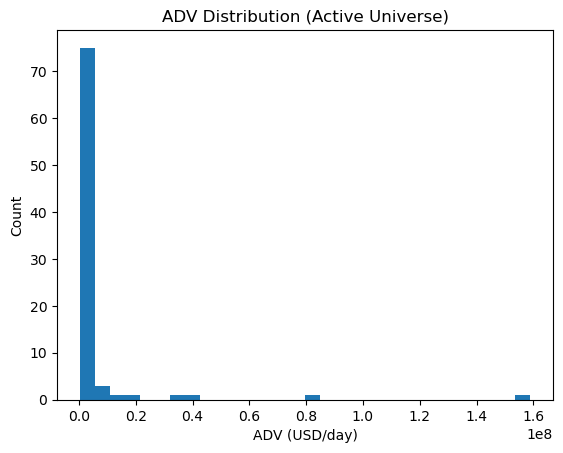

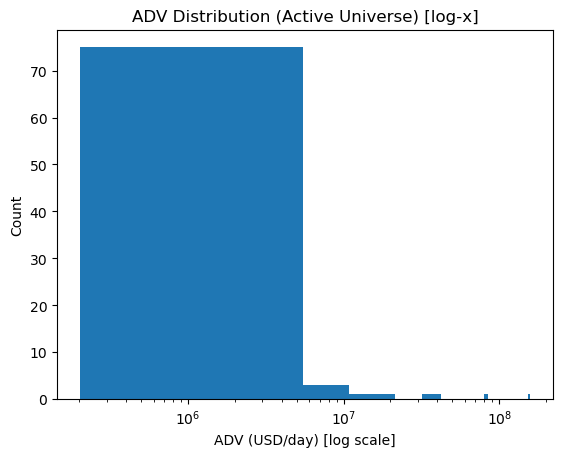


=== Concentration ===
Total ADV (active): 447,545,385 USD/day
Top 10 ADV: 377,085,210 USD/day
Top 10 share: 84.26%

Top 10 names:
      wsname      adv_usd
     XBT/USD 1.589754e+08
     ETH/USD 8.338298e+07
     SOL/USD 4.230568e+07
     XRP/USD 3.575284e+07
     ZEC/USD 1.668465e+07
     SUI/USD 1.257309e+07
     XMR/USD 8.570619e+06
     XDG/USD 7.351478e+06
     ADA/USD 6.633488e+06
FARTCOIN/USD 4.854958e+06

=== Spread Summary (bps) ===
      wsname  spread_median_bps  spread_p90_bps  n_samples
    RAVE/USD          91.727141      114.494049        337
    ZBCN/USD          69.268067      106.211037        337
     DOG/USD          53.561864       64.724919        337
       H/USD          42.338857       62.990131        337
    LUNA/USD          40.382286       59.267241        337
     OOB/USD          36.643459       36.643459        337
     PTB/USD          32.813782       49.504950        337
     KTA/USD          27.564481       35.440047        337
 USELESS/USD          

In [424]:
# Assuming you already have panel_b and panel_c from your pipeline:
results = run_universe_sanity_checks(
    panel_b=panel_b,
    panel_c=panel_c,
    eval_date="2026-02-01",
    do_spreads=True,        # set False if you want to skip for speed initially
    spread_days=14,         # 7 or 14
    spread_freq="1H",
    spread_sleep_s=0.03     # adjust to be polite; increase if you see throttling
)

## Final Universe Trimming

In [427]:
"""
Step 1 + Step 2: Build Core + Extended universes (Kraken) using
- Layer A hard excludes (already done previously)
- Liquidity metrics:
    * Rolling ADV (USD/day) from OHLC (volume * vwap)
    * Spread med / p90 (bps) from sampled best bid/ask
- Liquidity score:
    score = log(ADV) - λ * spread_median_bps - μ * spread_p90_bps
- Selection:
    Core: strict floors/caps
    Extended: looser floors/caps
- Layer C stability (optional in this block) can be applied after you have pass/fail per eval date.

Design goals:
- Simple, readable, robust.
- Small functions.
- Uses REST pair key ("pair") for API calls.
"""

from __future__ import annotations

import math
import time
import requests
import pandas as pd
from dataclasses import dataclass

# -----------------------
# Config
# -----------------------
KRAKEN_REST = "https://api.kraken.com"
SESSION = requests.Session()
SESSION.headers.update({"User-Agent": "kraken-universe-v2/1.0"})


@dataclass(frozen=True)
class UniverseRule:
    name: str
    adv_floor_usd: float
    spread_median_max_bps: float
    spread_p90_max_bps: float
    top_n: int


# Start with these; tune after one run
CORE = UniverseRule(name="core", adv_floor_usd=1_000_000, spread_median_max_bps=20, spread_p90_max_bps=40, top_n=60)
EXT  = UniverseRule(name="extended", adv_floor_usd=500_000, spread_median_max_bps=25, spread_p90_max_bps=50, top_n=100)

ADV_WINDOW_DAYS = 60
ADV_MIN_FRAC = 0.35          # relaxed; increase later
EVAL_FREQ = "MS"             # monthly. Try "2W" for faster adaptation
INTERVAL_MIN = 240           # 4h bars
SLEEP_OHLC = 0.03            # politeness per OHLC call
SLEEP_DEPTH = 0.05           # politeness per depth call


# -----------------------
# Kraken helpers
# -----------------------
def kraken_get(path: str, params: dict | None = None, timeout: int = 30) -> dict:
    url = f"{KRAKEN_REST}{path}"
    r = SESSION.get(url, params=params or {}, timeout=timeout)
    r.raise_for_status()
    j = r.json()
    if j.get("error"):
        raise RuntimeError(f"Kraken error {path}: {j['error']}")
    return j["result"]


def get_assetpairs() -> pd.DataFrame:
    res = kraken_get("/0/public/AssetPairs")
    rows = []
    for rest_pair, meta in res.items():
        rows.append({
            "pair": rest_pair,         # <- use for OHLC/Depth
            "wsname": meta.get("wsname"),
            "altname": meta.get("altname"),
            "base": meta.get("base"),
            "quote": meta.get("quote"),
            "status": meta.get("status"),
        })
    return pd.DataFrame(rows)


def get_ohlc(pair: str, interval_min: int = 240) -> pd.DataFrame:
    res = kraken_get("/0/public/OHLC", params={"pair": pair, "interval": interval_min})
    pair_key = next(k for k in res.keys() if k != "last")
    rows = res[pair_key]
    if not rows:
        return pd.DataFrame()
    cols = ["time","open","high","low","close","vwap","volume","count"]
    df = pd.DataFrame(rows, columns=cols)
    df["time"] = pd.to_datetime(df["time"], unit="s", utc=True)
    df = df.set_index("time").sort_index()
    df[["vwap","volume"]] = df[["vwap","volume"]].astype(float)
    return df[["vwap","volume"]]


def best_spread_bps(pair: str) -> float:
    res = kraken_get("/0/public/Depth", params={"pair": pair, "count": 1})
    key = next(iter(res.keys()))
    asks = res[key].get("asks", [])
    bids = res[key].get("bids", [])
    if not asks or not bids:
        return float("nan")
    ask = float(asks[0][0]); bid = float(bids[0][0])
    mid = 0.5 * (ask + bid)
    return float("nan") if mid <= 0 else (ask - bid) / mid * 1e4


# -----------------------
# Metrics: ADV + spreads
# -----------------------
def rolling_adv_usd(df_ohlc: pd.DataFrame, window_days: int, min_frac: float) -> pd.Series:
    # ADV USD proxy = sum(volume*vwap) per day, rolling mean
    daily = (df_ohlc["volume"] * df_ohlc["vwap"]).resample("1D").sum()
    min_periods = max(10, math.ceil(window_days * min_frac))
    return daily.rolling(window_days, min_periods=min_periods).mean()


def eval_dates_from_index(idx: pd.Index, eval_freq: str) -> pd.DatetimeIndex:
    start = idx.min().floor("D")
    end = idx.max().floor("D")
    return pd.date_range(start=start, end=end, freq=eval_freq, tz="UTC").floor("D")


def sample_spreads(pairs_df: pd.DataFrame, start_utc: pd.Timestamp, end_utc: pd.Timestamp, freq: str = "2H") -> pd.DataFrame:
    times = pd.date_range(start=start_utc, end=end_utc, freq=freq, tz="UTC")
    rows = []
    for ts in times:
        for _, r in pairs_df.iterrows():
            p = r["pair"]; w = r["wsname"]
            try:
                s = best_spread_bps(p)
            except Exception:
                s = float("nan")
            rows.append({"time": ts, "pair": p, "wsname": w, "spread_bps": s})
            time.sleep(SLEEP_DEPTH)
    return pd.DataFrame(rows)


def spread_stats(spread_samples: pd.DataFrame) -> pd.DataFrame:
    df = spread_samples.dropna(subset=["spread_bps"]).copy()
    g = df.groupby("pair")["spread_bps"]
    out = pd.DataFrame({
        "spread_median_bps": g.median(),
        "spread_p90_bps": g.quantile(0.9),
        "n_spread_samples": g.size(),
    }).reset_index()
    return out


# -----------------------
# Score + selection
# -----------------------
def liquidity_score(adv_usd: pd.Series, spread_med: pd.Series, spread_p90: pd.Series, lam: float = 0.03, mu: float = 0.01) -> pd.Series:
    """
    Score is unitless. ADV is heavy-tailed so log helps.
    lam/mu penalties are small numbers per bps; tune later.
    """
    return (adv_usd.clip(lower=1.0).apply(math.log)
            - lam * spread_med.fillna(1e9)
            - mu  * spread_p90.fillna(1e9))


def select_universe(snapshot: pd.DataFrame, rule: UniverseRule, lam: float = 0.03, mu: float = 0.01) -> pd.DataFrame:
    """
    snapshot columns required:
      pair, wsname, adv_usd, spread_median_bps, spread_p90_bps
    Returns rows for selected universe, with score.
    """
    df = snapshot.copy()

    # Hard gates
    df = df[df["adv_usd"] >= rule.adv_floor_usd]
    df = df[df["spread_median_bps"] <= rule.spread_median_max_bps]
    df = df[df["spread_p90_bps"] <= rule.spread_p90_max_bps]

    # Score + top N
    df["score"] = liquidity_score(df["adv_usd"], df["spread_median_bps"], df["spread_p90_bps"], lam=lam, mu=mu)
    df = df.sort_values("score", ascending=False).head(rule.top_n)

    df["universe"] = rule.name
    return df


# -----------------------
# Main: build core + extended at latest eval date
# -----------------------
def build_universe_snapshot(
    df_pairs_a: pd.DataFrame,
    eval_date: pd.Timestamp,
    spread_stats_df: pd.DataFrame,
) -> pd.DataFrame:
    """
    Build a single-date snapshot table with adv + spreads for selection.
    """
    # Pull OHLC for each pair, compute ADV series, then pick value up to eval_date
    rows = []
    for _, r in df_pairs_a.iterrows():
        p = r["pair"]; w = r["wsname"]
        try:
            ohlc = get_ohlc(p, interval_min=INTERVAL_MIN)
            if ohlc.empty:
                continue
            adv = rolling_adv_usd(ohlc, ADV_WINDOW_DAYS, ADV_MIN_FRAC).dropna()
            adv_val = float(adv.loc[:eval_date].iloc[-1]) if len(adv.loc[:eval_date]) else float("nan")
        except Exception:
            adv_val = float("nan")

        rows.append({"pair": p, "wsname": w, "adv_usd": adv_val})
        time.sleep(SLEEP_OHLC)

    snap = pd.DataFrame(rows).dropna(subset=["adv_usd"])
    snap = snap.merge(spread_stats_df, on="pair", how="left")

    # If a pair has no spread samples, treat it as bad (will be filtered out)
    snap["spread_median_bps"] = snap["spread_median_bps"].fillna(1e9)
    snap["spread_p90_bps"] = snap["spread_p90_bps"].fillna(1e9)
    return snap


# -----------------------
# Usage
# -----------------------
# 1) df_pairs_a should be your Layer A output (588 rows in your run).
#    If you already have df_pairs_a, skip this.
def layer_a_is_excluded(wsname: str) -> bool:
    w = (wsname or "").strip().upper()
    fx = {"AUD/USD", "EUR/USD", "GBP/USD"}
    stables = {
        "USDC/USD","USDT/USD","DAI/USD","PYUSD/USD","RLUSD/USD",
        "USDD/USD","USDE/USD","USDR/USD","USDS/USD",
        "USD1/USD","USDG/USD","USDQ/USD","USDUC/USD",
        "AUSD/USD","AUDX/USD","EURC/USD","EUROP/USD","EURQ/USD","EURR/USD",
        "TGBP/USD","BRL1/USD","CASH/USD","MXNB/USD"
    }
    commodities = {"PAXG/USD","XAUT/USD"}
    synthetics = {"WBTC/USD","TBTC/USD","METH/USD","LSETH/USD","CMETH/USD","JITOSOL/USD","LSSOL/USD","MSOL/USD"}
    return (w in fx) or (w in stables) or (w in commodities) or (w in synthetics)


def build_layer_a_pairs(quote_ccy: str = "ZUSD") -> pd.DataFrame:
    df = get_assetpairs()
    df = df[(df["status"] == "online") & (df["quote"] == quote_ccy)].copy()
    df = df[df["wsname"].notna()].copy()
    df = df[~df["wsname"].apply(layer_a_is_excluded)].copy()
    return df[["pair","wsname","altname","base","quote","status"]].reset_index(drop=True)


# -----------------------
# Run Step 1 + Step 2
# -----------------------
if __name__ == "__main__":
    # Layer A universe
    df_pairs_a = build_layer_a_pairs(quote_ccy="ZUSD")
    print("Layer A size:", len(df_pairs_a))

    # Choose a spread sampling window (keep short initially)
    now = pd.Timestamp.utcnow()
    end_utc = (now.tz_convert("UTC") if now.tzinfo is not None else now.tz_localize("UTC")).floor("H")
    start_utc = end_utc - pd.Timedelta(days=3)

    # Sample spreads on Layer A universe? That's huge (588). Instead:
    #  - sample spreads on a first-pass smaller set: top 200 by ADV proxy from OHLC
    # For simplicity, we do a cheap prefilter: compute one ADV snapshot (latest) and take top 200.
    # This keeps spread sampling tractable.
    eval_date = pd.Timestamp("2026-02-01", tz="UTC")  # you can set to your latest eval date

    # Quick ADV-only prefilter (top 200) to limit spread calls
    adv_rows = []
    for _, r in df_pairs_a.iterrows():
        p, w = r["pair"], r["wsname"]
        try:
            ohlc = get_ohlc(p, interval_min=INTERVAL_MIN)
            if ohlc.empty:
                continue
            adv = rolling_adv_usd(ohlc, ADV_WINDOW_DAYS, ADV_MIN_FRAC).dropna()
            adv_val = float(adv.loc[:eval_date].iloc[-1]) if len(adv.loc[:eval_date]) else float("nan")
        except Exception:
            adv_val = float("nan")
        adv_rows.append({"pair": p, "wsname": w, "adv_usd": adv_val})
        time.sleep(SLEEP_OHLC)

    adv_pref = pd.DataFrame(adv_rows).dropna(subset=["adv_usd"]).sort_values("adv_usd", ascending=False)
    df_pref = adv_pref.head(200)[["pair","wsname"]].merge(df_pairs_a, on=["pair","wsname"], how="left")
    print("Prefilter pairs for spread sampling:", len(df_pref))

    # Spread sampling on prefiltered set
    spreads = sample_spreads(df_pref[["pair","wsname"]], start_utc=start_utc, end_utc=end_utc, freq="2H")
    spread_df = spread_stats(spreads)

    # Build final snapshot with adv + spreads for selection
    snap = build_universe_snapshot(df_pref[["pair","wsname"]], eval_date=eval_date, spread_stats_df=spread_df)

    # Select Core + Extended universes
    core = select_universe(snap, CORE, lam=0.03, mu=0.01)
    ext = select_universe(snap, EXT, lam=0.03, mu=0.01)

    print("\nCORE universe size:", len(core))
    print(core[["wsname","adv_usd","spread_median_bps","spread_p90_bps","score"]].head(25).to_string(index=False))

    print("\nEXTENDED universe size:", len(ext))
    print(ext[["wsname","adv_usd","spread_median_bps","spread_p90_bps","score"]].head(25).to_string(index=False))

    # Optional: save
    # core.to_csv("kraken_universe_core.csv", index=False)
    # ext.to_csv("kraken_universe_extended.csv", index=False)

Layer A size: 589
Prefilter pairs for spread sampling: 200

CORE universe size: 34
      wsname      adv_usd  spread_median_bps  spread_p90_bps     score
     XBT/USD 1.589754e+08           0.014830        0.014855 18.883667
     ETH/USD 8.338298e+07           0.049286        1.389750 18.223579
     SOL/USD 4.230568e+07           1.147644        2.296950 17.503033
     XRP/USD 3.575284e+07           0.997194        1.847292 17.343752
     ZEC/USD 1.668465e+07           4.997709        8.473375 16.395334
     SUI/USD 1.257309e+07           2.124947        4.655122 16.236769
     XDG/USD 7.351478e+06           0.968086        1.690100 15.764468
     XMR/USD 8.570619e+06           8.916630       12.680975 15.569542
     ADA/USD 6.633488e+06           3.465652        5.161121 15.552061
     LTC/USD 3.716654e+06           3.573343        5.361451 14.967520
    LINK/USD 3.525941e+06           3.242350        4.754455 14.930843
FARTCOIN/USD 4.854958e+06          11.757790       11.809165 14.9

In [433]:
core

,pair,wsname,adv_usd,spread_median_bps,spread_p90_bps,n_spread_samples,score,universe
0,XXBTZUSD,XBT/USD,1.589754e+08,0.014830,0.014855,37,18.883667,core
1,XETHZUSD,ETH/USD,8.338298e+07,0.049286,1.389750,37,18.223579,core
2,SOLUSD,SOL/USD,4.230568e+07,1.147644,2.296950,37,17.503033,core
3,XXRPZUSD,XRP/USD,3.575284e+07,0.997194,1.847292,37,17.343752,core
4,XZECZUSD,ZEC/USD,1.668465e+07,4.997709,8.473375,37,16.395334,core
5,SUIUSD,SUI/USD,1.257309e+07,2.124947,4.655122,37,16.236769,core
7,XDGUSD,XDG/USD,7.351478e+06,0.968086,1.690100,37,15.764468,core
6,XXMRZUSD,XMR/USD,8.570619e+06,8.916630,12.680975,37,15.569542,core
8,ADAUSD,ADA/USD,6.633488e+06,3.465652,5.161121,37,15.552061,core
11,XLTCZUSD,LTC/USD,3.716654e+06,3.573343,5.361451,37,14.967520,core


In [437]:
ext

,pair,wsname,adv_usd,spread_median_bps,spread_p90_bps,n_spread_samples,score,universe
0,XXBTZUSD,XBT/USD,1.589754e+08,0.014830,0.014855,37,18.883667,extended
1,XETHZUSD,ETH/USD,8.338298e+07,0.049286,1.389750,37,18.223579,extended
2,SOLUSD,SOL/USD,4.230568e+07,1.147644,2.296950,37,17.503033,extended
3,XXRPZUSD,XRP/USD,3.575284e+07,0.997194,1.847292,37,17.343752,extended
4,XZECZUSD,ZEC/USD,1.668465e+07,4.997709,8.473375,37,16.395334,extended
5,SUIUSD,SUI/USD,1.257309e+07,2.124947,4.655122,37,16.236769,extended
7,XDGUSD,XDG/USD,7.351478e+06,0.968086,1.690100,37,15.764468,extended
6,XXMRZUSD,XMR/USD,8.570619e+06,8.916630,12.680975,37,15.569542,extended
8,ADAUSD,ADA/USD,6.633488e+06,3.465652,5.161121,37,15.552061,extended
11,XLTCZUSD,LTC/USD,3.716654e+06,3.573343,5.361451,37,14.967520,extended


## QA the Core & Extended Universe

In [514]:
"""
Append the code below to your existing script.

It adds 3 runnable tests that reuse your existing helpers:
  1) QA report (spreads/ADV/sample counts + "execution traps")
  2) Stability / churn test (build Core/Ext across eval dates; churn table)
  3) Smoke backtests (cross-sectional momentum + low-vol tilt) with simple costs

Notes:
- Churn test reuses the SAME spread_stats_df for all eval dates by default (fast).
  If you want, you can resample spreads per eval date (slow).
- Smoke tests use DAILY closes derived from 4h OHLC closes.
"""

from __future__ import annotations

import math
import time
from dataclasses import dataclass
from typing import Dict, Iterable, List, Optional, Tuple

import numpy as np
import pandas as pd


# ------------------------------------------------------------
# 0) Minimal extension: fetch close as well (reuses kraken_get)
# ------------------------------------------------------------
def get_ohlc_price(pair: str, interval_min: int = 240) -> pd.DataFrame:
    """
    Reuses Kraken OHLC but returns close + vwap + volume for backtests.
    """
    res = kraken_get("/0/public/OHLC", params={"pair": pair, "interval": interval_min})
    pair_key = next(k for k in res.keys() if k != "last")
    rows = res[pair_key]
    if not rows:
        return pd.DataFrame()

    cols = ["time","open","high","low","close","vwap","volume","count"]
    df = pd.DataFrame(rows, columns=cols)
    df["time"] = pd.to_datetime(df["time"], unit="s", utc=True)
    df = df.set_index("time").sort_index()

    df[["close","vwap","volume"]] = df[["close","vwap","volume"]].astype(float)
    return df[["close","vwap","volume"]]


# ------------------------------------------------------------
# 1) QA report on snapshot (spread/ADV sanity + traps)
# ------------------------------------------------------------
def universe_qa_report(
    snapshot: pd.DataFrame,
    adv_floor_usd: float = 500_000,
    min_spread_samples: int = 30,
    spread_p90_warn_bps: float = 50.0,
) -> Dict[str, object]:
    """
    snapshot columns expected:
      pair, wsname, adv_usd, spread_median_bps, spread_p90_bps, n_spread_samples (optional), score(optional)
    Returns a dict of summaries + (optional) DataFrames.
    """
    df = snapshot.copy()

    out: Dict[str, object] = {}
    out["n_pairs"] = int(len(df))
    out["adv_usd_summary"] = df["adv_usd"].describe()
    out["spread_median_bps_summary"] = df["spread_median_bps"].describe()
    out["spread_p90_bps_summary"] = df["spread_p90_bps"].describe()

    if "n_spread_samples" in df.columns:
        low_n = df[df["n_spread_samples"] < min_spread_samples] \
            .sort_values("n_spread_samples")[["wsname","pair","n_spread_samples","adv_usd","spread_median_bps","spread_p90_bps"]]
        out["low_spread_sample_pairs"] = low_n

    # Execution traps: low-ish ADV + bad tail spread
    traps = df[(df["adv_usd"] < adv_floor_usd) & (df["spread_p90_bps"] >= spread_p90_warn_bps)] \
        .sort_values(["spread_p90_bps","spread_median_bps"], ascending=False)
    cols = ["wsname","pair","adv_usd","spread_median_bps","spread_p90_bps"]
    if "score" in df.columns:
        cols.append("score")
    out["execution_traps"] = traps[cols].head(50)

    # Borderline around ADV floor (tuning aid)
    df2 = df.assign(adv_ratio=df["adv_usd"] / max(1.0, adv_floor_usd))
    out["near_adv_floor"] = df2.query("adv_ratio < 1.5") \
        .sort_values("adv_ratio")[["wsname","pair","adv_usd","adv_ratio","spread_median_bps","spread_p90_bps"]].head(50)

    return out


def print_qa_report(qa: Dict[str, object]) -> None:
    print("\n--- QA SUMMARY ---")
    print("n_pairs:", qa["n_pairs"])
    print("\nADV summary:\n", qa["adv_usd_summary"])
    print("\nSpread median summary:\n", qa["spread_median_bps_summary"])
    print("\nSpread p90 summary:\n", qa["spread_p90_bps_summary"])

    if "low_spread_sample_pairs" in qa:
        df = qa["low_spread_sample_pairs"]
        print("\nPairs with low spread sample count:\n", df.head(20).to_string(index=False))

    df_traps = qa["execution_traps"]
    print("\nExecution traps (low ADV + high spread tail):\n", df_traps.head(25).to_string(index=False))

    df_border = qa["near_adv_floor"]
    print("\nNear ADV floor:\n", df_border.head(25).to_string(index=False))


# ------------------------------------------------------------
# 2) Stability / churn test (fast version: reuse same spreads)
# ------------------------------------------------------------
def build_ohlc_cache(
    pairs_df: pd.DataFrame,
    interval_min: int = 240,
    sleep_s: float = 0.03,
    use_close: bool = False,
) -> Dict[str, pd.DataFrame]:
    """
    Cache OHLC per pair so you don't refetch repeatedly.
    pairs_df must contain column "pair".
    If use_close=True, fetches close+vwap+volume; else uses get_ohlc (vwap+volume).
    """
    cache: Dict[str, pd.DataFrame] = {}
    for _, r in pairs_df.iterrows():
        p = r["pair"]
        try:
            df = get_ohlc_price(p, interval_min=interval_min) if use_close else get_ohlc(p, interval_min=interval_min)
            if df is not None and not df.empty:
                cache[p] = df
        except Exception:
            pass
        time.sleep(sleep_s)
    return cache


def adv_at_eval_date_from_cache(
    ohlc_df: pd.DataFrame,
    eval_date: pd.Timestamp,
    window_days: int,
    min_frac: float,
) -> float:
    adv = rolling_adv_usd(ohlc_df, window_days, min_frac).dropna()
    if adv.empty:
        return float("nan")
    s = adv.loc[:eval_date]
    return float(s.iloc[-1]) if len(s) else float("nan")


def build_universe_snapshot_from_cache(
    df_pairs: pd.DataFrame,
    eval_date: pd.Timestamp,
    spread_stats_df: pd.DataFrame,
    ohlc_cache: dict[str, pd.DataFrame],
) -> pd.DataFrame:
    rows = []
    for _, r in df_pairs.iterrows():
        p = r["pair"]; w = r["wsname"]
        ohlc = ohlc_cache.get(p)
        if ohlc is None or ohlc.empty:
            continue

        try:
            adv_val = adv_at_eval_date_from_cache(ohlc, eval_date, ADV_WINDOW_DAYS, ADV_MIN_FRAC)
        except Exception:
            adv_val = float("nan")

        if math.isfinite(adv_val):
            rows.append({"pair": p, "wsname": w, "adv_usd": float(adv_val)})

    # IMPORTANT: handle empty rows
    if not rows:
        # Return an empty snapshot with the columns select_universe expects
        return pd.DataFrame(columns=[
            "pair","wsname","adv_usd","spread_median_bps","spread_p90_bps","n_spread_samples"
        ])

    snap = pd.DataFrame(rows)

    # merge spreads
    snap = snap.merge(spread_stats_df, on="pair", how="left")

    # missing spreads => bad
    snap["spread_median_bps"] = snap["spread_median_bps"].fillna(1e9)
    snap["spread_p90_bps"] = snap["spread_p90_bps"].fillna(1e9)

    # keep sample count if present
    if "n_spread_samples" not in snap.columns and "n_spread_samples" in spread_stats_df.columns:
        snap["n_spread_samples"] = np.nan

    return snap


def universes_over_eval_dates(
    df_pairs: pd.DataFrame,
    eval_dates: pd.DatetimeIndex,
    spread_stats_df: pd.DataFrame,
    ohlc_cache: Dict[str, pd.DataFrame],
    rule: UniverseRule,
    lam: float = 0.03,
    mu: float = 0.01,
) -> Dict[pd.Timestamp, set]:
    out: Dict[pd.Timestamp, set] = {}
    for d in eval_dates:
        snap_d = build_universe_snapshot_from_cache(df_pairs, d, spread_stats_df, ohlc_cache)
        uni_d = select_universe(snap_d, rule, lam=lam, mu=mu)
        out[d] = set(uni_d["pair"].tolist())
    return out


def churn_table(universe_by_date: Dict[pd.Timestamp, set]) -> pd.DataFrame:
    dates = sorted(universe_by_date.keys())
    rows = []
    for i in range(1, len(dates)):
        d0, d1 = dates[i-1], dates[i]
        u0, u1 = universe_by_date[d0], universe_by_date[d1]
        entered = u1 - u0
        exited = u0 - u1
        churn = (len(entered) + len(exited)) / max(1, len(u0))
        rows.append({
            "date": d1,
            "prev_date": d0,
            "size": len(u1),
            "entered": len(entered),
            "exited": len(exited),
            "churn": churn,
        })
    return pd.DataFrame(rows)


# ------------------------------------------------------------
# 3) Smoke backtests (daily) with simple transaction cost model
# ------------------------------------------------------------
@dataclass(frozen=True)
class SmokeCostModel:
    fee_bps_one_way: float = 6.0          # set to your taker fee (or average)
    half_spread_frac: float = 0.5         # assume you cross half-spread
    extra_slip_bps: float = 0.0           # optional extra slippage


def build_daily_close_panel(
    universe_df: pd.DataFrame,
    interval_min: int = 240,
    sleep_s: float = 0.03,
    lookback_days: int = 180,
) -> Tuple[pd.DataFrame, pd.DataFrame]:
    """
    Fetch 4h OHLC close for each pair in universe_df and return:
      - daily close panel: index=day, columns=pair, values=close
      - meta table with wsname/spread stats (to map costs)
    """
    pairs = universe_df[["pair","wsname","spread_median_bps","spread_p90_bps"]].copy()
    cache = build_ohlc_cache(pairs[["pair"]], interval_min=interval_min, sleep_s=sleep_s, use_close=True)

    daily = {}
    for _, r in pairs.iterrows():
        p = r["pair"]
        df = cache.get(p)
        if df is None or df.empty:
            continue
        # daily close from 4h close
        s = df["close"].resample("1D").last()
        daily[p] = s

    px = pd.DataFrame(daily).sort_index()
    if len(px) > lookback_days:
        px = px.iloc[-lookback_days:]

    return px, pairs.set_index("pair")


def _build_cost_bps_per_pair(meta_by_pair: pd.DataFrame, cost: SmokeCostModel) -> pd.Series:
    # per $ notional traded, 1-way cost in bps:
    # fee + half_spread + extra_slip
    half_spread = cost.half_spread_frac * meta_by_pair["spread_median_bps"].astype(float)
    c = cost.fee_bps_one_way + half_spread + cost.extra_slip_bps
    return c.reindex(meta_by_pair.index)


def _perf_stats(daily_ret: pd.Series, ann_factor: int = 365) -> dict:
    r = daily_ret.dropna()
    if r.empty:
        return {}
    eq = (1 + r).cumprod()
    cagr = eq.iloc[-1] ** (ann_factor / len(r)) - 1
    ann_vol = r.std() * math.sqrt(ann_factor)
    sharpe = (r.mean() * ann_factor) / (r.std() * math.sqrt(ann_factor)) if r.std() > 0 else float("nan")
    peak = eq.cummax()
    dd = eq / peak - 1
    mdd = dd.min()
    return {"cagr": float(cagr), "ann_vol": float(ann_vol), "sharpe": float(sharpe), "max_drawdown": float(mdd)}


def backtest_xs_momentum(
    px_daily: pd.DataFrame,
    meta_by_pair: pd.DataFrame,
    k: int = 10,
    lookback_days: int = 7,
    rebalance_every_days: int = 1,
    cost: SmokeCostModel = SmokeCostModel(),
) -> Dict[str, object]:
    """
    Cross-sectional momentum:
      rank by (P_t / P_{t-L} - 1), long top-k equal weight.
    Costs:
      cost_t = sum_i |dw_i| * cost_bps_i / 1e4
    """
    px = px_daily.copy().dropna(how="all")
    rets = px.pct_change()

    mom = px.pct_change(lookback_days)

    pairs = px.columns.tolist()
    w = pd.DataFrame(0.0, index=px.index, columns=pairs)

    last_w = pd.Series(0.0, index=pairs)
    for t, dt in enumerate(px.index):
        if t < lookback_days:
            w.loc[dt] = last_w
            continue

        # rebalance schedule
        if ((t - lookback_days) % rebalance_every_days) != 0:
            w.loc[dt] = last_w
            continue

        sig = mom.loc[dt].dropna().sort_values(ascending=False)
        top = sig.head(k).index.tolist()
        new_w = pd.Series(0.0, index=pairs)
        if len(top) > 0:
            new_w[top] = 1.0 / len(top)

        last_w = new_w
        w.loc[dt] = last_w

    w = w.ffill().fillna(0.0)

    # costs
    cost_bps = _build_cost_bps_per_pair(meta_by_pair, cost)
    dw = w.diff().abs().fillna(0.0)
    cost_daily = (dw.mul(cost_bps, axis=1).sum(axis=1)) / 1e4

    # portfolio returns (apply weights from previous day)
    gross = (w.shift(1).fillna(0.0) * rets).sum(axis=1).fillna(0.0)
    net = gross - cost_daily

    out = {
        "weights": w,
        "gross_daily_ret": gross,
        "net_daily_ret": net,
        "cost_daily": cost_daily,
        "stats_gross": _perf_stats(gross),
        "stats_net": _perf_stats(net),
    }
    return out


def backtest_low_vol_tilt(
    px_daily: pd.DataFrame,
    meta_by_pair: pd.DataFrame,
    k: int = 10,
    vol_lookback_days: int = 14,
    rebalance_every_days: int = 1,
    inv_vol_weight: bool = True,
    cost: SmokeCostModel = SmokeCostModel(),
) -> Dict[str, object]:
    """
    Low-vol tilt:
      rank by trailing vol of daily returns, long lowest-k.
      weights = inverse-vol (optional) else equal.
    """
    px = px_daily.copy().dropna(how="all")
    rets = px.pct_change()

    vol = rets.rolling(vol_lookback_days).std()

    pairs = px.columns.tolist()
    w = pd.DataFrame(0.0, index=px.index, columns=pairs)

    last_w = pd.Series(0.0, index=pairs)
    for t, dt in enumerate(px.index):
        if t < vol_lookback_days:
            w.loc[dt] = last_w
            continue

        if ((t - vol_lookback_days) % rebalance_every_days) != 0:
            w.loc[dt] = last_w
            continue

        sig = vol.loc[dt].dropna().sort_values(ascending=True)  # lowest vol first
        sel = sig.head(k)
        chosen = sel.index.tolist()

        new_w = pd.Series(0.0, index=pairs)
        if len(chosen) > 0:
            if inv_vol_weight:
                inv = (1.0 / sel.replace(0.0, np.nan)).fillna(0.0)
                s = float(inv.sum())
                if s > 0:
                    new_w[chosen] = (inv / s).values
                else:
                    new_w[chosen] = 1.0 / len(chosen)
            else:
                new_w[chosen] = 1.0 / len(chosen)

        last_w = new_w
        w.loc[dt] = last_w

    w = w.ffill().fillna(0.0)

    # costs
    cost_bps = _build_cost_bps_per_pair(meta_by_pair, cost)
    dw = w.diff().abs().fillna(0.0)
    cost_daily = (dw.mul(cost_bps, axis=1).sum(axis=1)) / 1e4

    gross = (w.shift(1).fillna(0.0) * rets).sum(axis=1).fillna(0.0)
    net = gross - cost_daily

    out = {
        "weights": w,
        "gross_daily_ret": gross,
        "net_daily_ret": net,
        "cost_daily": cost_daily,
        "stats_gross": _perf_stats(gross),
        "stats_net": _perf_stats(net),
    }
    return out


# ------------------------------------------------------------
# Example: how to call the 3 tests right after you build snap/core/ext
# ------------------------------------------------------------
def run_all_tests_example(
    snap: pd.DataFrame,
    core: pd.DataFrame,
    ext: pd.DataFrame,
    df_pref: pd.DataFrame,
    spread_df: pd.DataFrame,
    eval_freq_for_churn: str = "2W",
    churn_n_periods: int = 8,
) -> None:
    """
    Call this after your Step 1+2 universe build finishes.
    """

    # ---------------- QA on the candidate snapshot ----------------
    qa = universe_qa_report(
        snapshot=snap,   # already has the columns you need
        adv_floor_usd=EXT.adv_floor_usd,
        min_spread_samples=20,
        spread_p90_warn_bps=EXT.spread_p90_max_bps,
    )
    print_qa_report(qa)

    # ---------------- Churn test (fast) ----------------
    # Build eval_dates over available OHLC history using cache (ADV changes drive churn)
    print("\n--- BUILDING OHLC CACHE FOR CHURN TEST (prefilter set) ---")
    ohlc_cache = build_ohlc_cache(df_pref[["pair"]], interval_min=INTERVAL_MIN, sleep_s=SLEEP_OHLC, use_close=False)

    # pick eval_dates based on the MIN/MAX index across cache (approx)
    # (use first cached series to infer range)
    any_df = next(iter(ohlc_cache.values()))
    eval_dates = eval_dates_from_index(any_df.index, eval_freq_for_churn)
    if len(eval_dates) > churn_n_periods:
        eval_dates = eval_dates[-churn_n_periods:]

    print("\n--- CHURN TEST: CORE ---")
    core_by_d = universes_over_eval_dates(df_pref[["pair","wsname"]], eval_dates, spread_df, ohlc_cache, CORE)
    df_churn_core = churn_table(core_by_d)
    print(df_churn_core.to_string(index=False))

    print("\n--- CHURN TEST: EXTENDED ---")
    ext_by_d = universes_over_eval_dates(df_pref[["pair","wsname"]], eval_dates, spread_df, ohlc_cache, EXT)
    df_churn_ext = churn_table(ext_by_d)
    print(df_churn_ext.to_string(index=False))

    # ---------------- Smoke tests (run on Core and Extended) ----------------
    print("\n--- SMOKE TESTS: CORE ---")
    px_core, meta_core = build_daily_close_panel(core, interval_min=INTERVAL_MIN, sleep_s=SLEEP_OHLC, lookback_days=180)
    cost_model = SmokeCostModel(fee_bps_one_way=6.0, half_spread_frac=0.5, extra_slip_bps=0.0)

    mom_core = backtest_xs_momentum(px_core, meta_core, k=min(10, px_core.shape[1]), lookback_days=7, rebalance_every_days=1, cost=cost_model)
    lv_core  = backtest_low_vol_tilt(px_core, meta_core, k=min(10, px_core.shape[1]), vol_lookback_days=14, rebalance_every_days=1, inv_vol_weight=True, cost=cost_model)

    print("Momentum CORE stats (gross):", mom_core["stats_gross"])
    print("Momentum CORE stats (net):  ", mom_core["stats_net"])
    print("LowVol CORE stats (gross):  ", lv_core["stats_gross"])
    print("LowVol CORE stats (net):    ", lv_core["stats_net"])

    print("\n--- SMOKE TESTS: EXTENDED ---")
    px_ext, meta_ext = build_daily_close_panel(ext, interval_min=INTERVAL_MIN, sleep_s=SLEEP_OHLC, lookback_days=180)

    mom_ext = backtest_xs_momentum(px_ext, meta_ext, k=min(15, px_ext.shape[1]), lookback_days=7, rebalance_every_days=1, cost=cost_model)
    lv_ext  = backtest_low_vol_tilt(px_ext, meta_ext, k=min(15, px_ext.shape[1]), vol_lookback_days=14, rebalance_every_days=1, inv_vol_weight=True, cost=cost_model)

    print("Momentum EXT stats (gross):", mom_ext["stats_gross"])
    print("Momentum EXT stats (net):  ", mom_ext["stats_net"])
    print("LowVol EXT stats (gross):  ", lv_ext["stats_gross"])
    print("LowVol EXT stats (net):    ", lv_ext["stats_net"])

In [516]:


"""
HOW TO USE (in your __main__):

After you compute:
  snap = build_universe_snapshot(...)
  core = select_universe(snap, CORE, ...)
  ext  = select_universe(snap, EXT,  ...)

Add:
  run_all_tests_example(
      snap=snap,
      core=core,
      ext=ext,
      df_pref=df_pref,        # your spread-sampled prefilter set (top 200)
      spread_df=spread_df,    # output of spread_stats(spreads)
      eval_freq_for_churn="2W",
      churn_n_periods=8,
  )
"""

'\nHOW TO USE (in your __main__):\n\nAfter you compute:\n  snap = build_universe_snapshot(...)\n  core = select_universe(snap, CORE, ...)\n  ext  = select_universe(snap, EXT,  ...)\n\nAdd:\n  run_all_tests_example(\n      snap=snap,\n      core=core,\n      ext=ext,\n      df_pref=df_pref,        # your spread-sampled prefilter set (top 200)\n      spread_df=spread_df,    # output of spread_stats(spreads)\n      eval_freq_for_churn="2W",\n      churn_n_periods=8,\n  )\n'

In [462]:
snap.head()

,pair,wsname,adv_usd,spread_median_bps,spread_p90_bps,n_spread_samples
0,XXBTZUSD,XBT/USD,1.589754e+08,0.014830,0.014855,37
1,XETHZUSD,ETH/USD,8.338298e+07,0.049286,1.389750,37
2,SOLUSD,SOL/USD,4.230568e+07,1.147644,2.296950,37
3,XXRPZUSD,XRP/USD,3.575284e+07,0.997194,1.847292,37
4,XZECZUSD,ZEC/USD,1.668465e+07,4.997709,8.473375,37


In [464]:
core.head()

,pair,wsname,adv_usd,spread_median_bps,spread_p90_bps,n_spread_samples,score,universe
0,XXBTZUSD,XBT/USD,1.589754e+08,0.014830,0.014855,37,18.883667,core
1,XETHZUSD,ETH/USD,8.338298e+07,0.049286,1.389750,37,18.223579,core
2,SOLUSD,SOL/USD,4.230568e+07,1.147644,2.296950,37,17.503033,core
3,XXRPZUSD,XRP/USD,3.575284e+07,0.997194,1.847292,37,17.343752,core
4,XZECZUSD,ZEC/USD,1.668465e+07,4.997709,8.473375,37,16.395334,core


In [466]:
ext.head()

,pair,wsname,adv_usd,spread_median_bps,spread_p90_bps,n_spread_samples,score,universe
0,XXBTZUSD,XBT/USD,1.589754e+08,0.014830,0.014855,37,18.883667,extended
1,XETHZUSD,ETH/USD,8.338298e+07,0.049286,1.389750,37,18.223579,extended
2,SOLUSD,SOL/USD,4.230568e+07,1.147644,2.296950,37,17.503033,extended
3,XXRPZUSD,XRP/USD,3.575284e+07,0.997194,1.847292,37,17.343752,extended
4,XZECZUSD,ZEC/USD,1.668465e+07,4.997709,8.473375,37,16.395334,extended


In [468]:
df_pref.head()

,pair,wsname,altname,base,quote,status
0,XXBTZUSD,XBT/USD,XBTUSD,XXBT,ZUSD,online
1,XETHZUSD,ETH/USD,ETHUSD,XETH,ZUSD,online
2,SOLUSD,SOL/USD,SOLUSD,SOL,ZUSD,online
3,XXRPZUSD,XRP/USD,XRPUSD,XXRP,ZUSD,online
4,XZECZUSD,ZEC/USD,ZECUSD,XZEC,ZUSD,online


In [470]:
spread_df.head()

,pair,spread_median_bps,spread_p90_bps,n_spread_samples
0,0GUSD,14.847810,20.730578,37
1,2ZUSD,9.925558,15.477719,37
2,AAVEUSD,5.166179,6.877098,37
3,ABUSD,20.777062,29.063733,37
4,ACHUSD,28.490028,28.571429,37


In [518]:
run_all_tests_example(
  snap=snap,
  core=core,
  ext=ext,
  df_pref=df_pref,        # your spread-sampled prefilter set (top 200)
  spread_df=spread_df,    # output of spread_stats(spreads)
  eval_freq_for_churn="2W",
  churn_n_periods=8,
)


--- QA SUMMARY ---
n_pairs: 200

ADV summary:
 count    2.000000e+02
mean     2.308818e+06
std      1.326013e+07
min      5.229192e+04
25%      8.967016e+04
50%      1.872126e+05
75%      5.484389e+05
max      1.589754e+08
Name: adv_usd, dtype: float64

Spread median summary:
 count     200.000000
mean       35.372047
std       183.869334
min         0.014830
25%         6.441639
50%        12.716282
75%        25.403900
max      2582.428697
Name: spread_median_bps, dtype: float64

Spread p90 summary:
 count     200.000000
mean       45.500124
std       185.949113
min         0.014855
25%        10.265461
50%        19.850392
75%        36.422560
max      2582.428697
Name: spread_p90_bps, dtype: float64

Pairs with low spread sample count:
 Empty DataFrame
Columns: [wsname, pair, n_spread_samples, adv_usd, spread_median_bps, spread_p90_bps]
Index: []

Execution traps (low ADV + high spread tail):
       wsname        pair       adv_usd  spread_median_bps  spread_p90_bps
   CHECK/USD  

In [520]:
core

,pair,wsname,adv_usd,spread_median_bps,spread_p90_bps,n_spread_samples,score,universe
0,XXBTZUSD,XBT/USD,1.589754e+08,0.014830,0.014855,37,18.883667,core
1,XETHZUSD,ETH/USD,8.338298e+07,0.049286,1.389750,37,18.223579,core
2,SOLUSD,SOL/USD,4.230568e+07,1.147644,2.296950,37,17.503033,core
3,XXRPZUSD,XRP/USD,3.575284e+07,0.997194,1.847292,37,17.343752,core
4,XZECZUSD,ZEC/USD,1.668465e+07,4.997709,8.473375,37,16.395334,core
5,SUIUSD,SUI/USD,1.257309e+07,2.124947,4.655122,37,16.236769,core
7,XDGUSD,XDG/USD,7.351478e+06,0.968086,1.690100,37,15.764468,core
6,XXMRZUSD,XMR/USD,8.570619e+06,8.916630,12.680975,37,15.569542,core
8,ADAUSD,ADA/USD,6.633488e+06,3.465652,5.161121,37,15.552061,core
11,XLTCZUSD,LTC/USD,3.716654e+06,3.573343,5.361451,37,14.967520,core


## Additional Tests on the Universe

In [531]:
"""
Drop-in code to:
1) Add hard safety excludes (extreme spreads / tiny ADV)
2) Add Layer C hysteresis (enter/exit confirmation) and re-run churn
3) Add diagnostic stats: turnover + cost/day Core vs Extended
4) Pull + save 4h OHLC for your chosen universe (factor research)

Assumes you already have:
- snap, core, ext, df_pref, spread_df from your Step1/2 run
- get_ohlc_price(), rolling_adv_usd(), select_universe(), build_ohlc_cache(), etc.

Keep functions small + readable.
"""

from __future__ import annotations
import math, time
import numpy as np
import pandas as pd


# -----------------------------
# 1) Hygiene filters (hard safety excludes)
# -----------------------------
def apply_safety_excludes(df: pd.DataFrame, adv_min_usd: float = 200_000, spread_p90_hard: float = 200.0) -> pd.DataFrame:
    x = df.copy()
    return x[(x["adv_usd"] >= adv_min_usd) & (x["spread_p90_bps"] <= spread_p90_hard)].copy()


def maybe_raise_extended_floor(ext_rule, new_adv_floor: float = 750_000):
    # helper: keep your dataclass immutable style
    return UniverseRule(
        name=ext_rule.name,
        adv_floor_usd=new_adv_floor,
        spread_median_max_bps=ext_rule.spread_median_max_bps,
        spread_p90_max_bps=ext_rule.spread_p90_max_bps,
        top_n=ext_rule.top_n,
    )


# -----------------------------
# 2) Layer C stability (hysteresis)
# -----------------------------
def set_from_df(df: pd.DataFrame) -> set[str]:
    return set(df["pair"].tolist())


def hysteresis_update(prev_set: set[str], candidates: set[str], pass_ct: dict[str,int], fail_ct: dict[str,int],
                      enter_k: int = 2, exit_k: int = 2) -> set[str]:
    """
    - pass_ct/fail_ct track consecutive pass/fail for each pair.
    - enter if pass_ct >= enter_k
    - exit if fail_ct >= exit_k
    """
    new_set = set(prev_set)

    # update counts
    for p in candidates:
        pass_ct[p] = pass_ct.get(p, 0) + 1
        fail_ct[p] = 0

    for p in list(pass_ct.keys()):
        if p not in candidates:
            fail_ct[p] = fail_ct.get(p, 0) + 1
            pass_ct[p] = 0

    # enter
    for p, c in pass_ct.items():
        if c >= enter_k:
            new_set.add(p)

    # exit
    for p, c in fail_ct.items():
        if c >= exit_k and p in new_set:
            new_set.remove(p)

    return new_set


def churn_rows(universe_by_date: dict[pd.Timestamp,set[str]]) -> pd.DataFrame:
    dates = sorted(universe_by_date.keys())
    rows = []
    for i in range(1, len(dates)):
        d0, d1 = dates[i-1], dates[i]
        u0, u1 = universe_by_date[d0], universe_by_date[d1]
        entered, exited = u1 - u0, u0 - u1
        denom = len(u0)
        churn = np.nan if denom == 0 else (len(entered) + len(exited)) / denom
        rows.append({"date": d1, "prev_date": d0, "size": len(u1),
                     "entered": len(entered), "exited": len(exited), "churn": churn})
    return pd.DataFrame(rows)


# -----------------------------
# 3) Build snapshots over eval dates (cache-based)
# -----------------------------
def eval_dates_from_cache(ohlc_cache: dict[str,pd.DataFrame], eval_freq: str) -> pd.DatetimeIndex:
    mins, maxs = [], []
    for df in ohlc_cache.values():
        if df is None or df.empty:
            continue
        mins.append(df.index.min())
        maxs.append(df.index.max())
    if not mins:
        return pd.DatetimeIndex([], tz="UTC")

    start = max(mins).floor("D")
    end = min(maxs).floor("D")
    if start >= end:  # fallback to union
        start = min(mins).floor("D")
        end = max(maxs).floor("D")

    return pd.date_range(start=start, end=end, freq=eval_freq, tz="UTC").floor("D")


def adv_at_date(df_ohlc: pd.DataFrame, eval_date: pd.Timestamp, window_days: int, min_frac: float) -> float:
    s = rolling_adv_usd(df_ohlc, window_days, min_frac).dropna()
    s = s.loc[:eval_date]
    return float("nan") if len(s) == 0 else float(s.iloc[-1])


def snapshot_from_cache(df_pairs: pd.DataFrame, eval_date: pd.Timestamp, spread_df: pd.DataFrame,
                        ohlc_cache: dict[str,pd.DataFrame]) -> pd.DataFrame:
    rows = []
    for _, r in df_pairs.iterrows():
        p, w = r["pair"], r["wsname"]
        o = ohlc_cache.get(p)
        if o is None or o.empty:
            continue
        adv = adv_at_date(o, eval_date, ADV_WINDOW_DAYS, ADV_MIN_FRAC)
        if math.isfinite(adv):
            rows.append({"pair": p, "wsname": w, "adv_usd": adv})

    if not rows:
        return pd.DataFrame(columns=["pair","wsname","adv_usd","spread_median_bps","spread_p90_bps","n_spread_samples"])

    snap = pd.DataFrame(rows).merge(spread_df, on="pair", how="left")
    snap["spread_median_bps"] = snap["spread_median_bps"].fillna(1e9)
    snap["spread_p90_bps"] = snap["spread_p90_bps"].fillna(1e9)
    return snap


def candidates_by_date(df_pairs: pd.DataFrame, eval_dates: pd.DatetimeIndex, spread_df: pd.DataFrame,
                       ohlc_cache: dict[str,pd.DataFrame], rule: UniverseRule,
                       adv_min_usd: float = 200_000, spread_p90_hard: float = 200.0,
                       lam: float = 0.03, mu: float = 0.01) -> dict[pd.Timestamp,set[str]]:
    out = {}
    for d in eval_dates:
        snap_d = snapshot_from_cache(df_pairs, d, spread_df, ohlc_cache)
        snap_d = apply_safety_excludes(snap_d, adv_min_usd=adv_min_usd, spread_p90_hard=spread_p90_hard)
        uni_d = select_universe(snap_d, rule, lam=lam, mu=mu)
        out[d] = set_from_df(uni_d)
    return out


def apply_hysteresis(universe_candidates: dict[pd.Timestamp,set[str]], enter_k: int = 2, exit_k: int = 2) -> dict[pd.Timestamp,set[str]]:
    dates = sorted(universe_candidates.keys())
    pass_ct, fail_ct = {}, {}
    out = {}
    current = set()
    for d in dates:
        current = hysteresis_update(current, universe_candidates[d], pass_ct, fail_ct, enter_k=enter_k, exit_k=exit_k)
        out[d] = set(current)
    return out


# -----------------------------
# 4) Diagnostic: turnover + cost/day (Core vs Ext)
# -----------------------------
def cost_bps_per_pair(meta_by_pair: pd.DataFrame, fee_bps_one_way: float = 6.0, half_spread_frac: float = 0.5, extra_slip_bps: float = 0.0) -> pd.Series:
    half_spread = half_spread_frac * meta_by_pair["spread_median_bps"].astype(float)
    return fee_bps_one_way + half_spread + extra_slip_bps


def turnover_and_cost(weights: pd.DataFrame, cost_bps: pd.Series) -> pd.DataFrame:
    dw = weights.diff().abs().fillna(0.0)
    turnover = dw.sum(axis=1)
    cost = (dw.mul(cost_bps, axis=1).sum(axis=1)) / 1e4
    return pd.DataFrame({"turnover": turnover, "cost": cost})


def summarize_turnover_cost(df_tc: pd.DataFrame) -> dict:
    x = df_tc.dropna()
    return {
        "avg_turnover_per_day": float(x["turnover"].mean()),
        "avg_cost_per_day": float(x["cost"].mean()),
        "p90_cost_per_day": float(x["cost"].quantile(0.9)),
        "n_days": int(len(x)),
    }


# -----------------------------
# 5) Pull + save 4h bars for final universe (factor research)
# -----------------------------
def fetch_4h_panel(pairs: list[str], interval_min: int = 240, sleep_s: float = 0.03) -> dict[str,pd.DataFrame]:
    cache = {}
    for p in pairs:
        try:
            df = get_ohlc_price(p, interval_min=interval_min)   # close+vwap+volume
            if df is not None and not df.empty:
                cache[p] = df
        except Exception:
            pass
        time.sleep(sleep_s)
    return cache


def save_4h_cache(cache: dict[str,pd.DataFrame], folder: str = "kraken_4h_cache") -> None:
    import os
    os.makedirs(folder, exist_ok=True)
    for pair, df in cache.items():
        fn = pair.replace("/", "_")
        df.to_parquet(f"{folder}/{fn}.parquet")


# -----------------------------
# RUNNER: universe refinement + churn + diagnostics + 4h pull
# -----------------------------
def run_universe_refinement_and_pull(
    df_pref: pd.DataFrame,
    spread_df: pd.DataFrame,
    core_rule: UniverseRule,
    ext_rule: UniverseRule,
    eval_freq: str = "2W",
    n_periods: int = 8,
    enter_k: int = 2,
    exit_k: int = 2,
    adv_min_usd: float = 200_000,
    spread_p90_hard: float = 200.0,
    fee_bps_one_way: float = 6.0,
) -> None:
    print("\n--- Build OHLC cache (for churn/snapshots) ---")
    ohlc_cache = build_ohlc_cache(df_pref[["pair"]], interval_min=INTERVAL_MIN, sleep_s=SLEEP_OHLC, use_close=False)
    print("cache_size:", len(ohlc_cache), "pref_size:", len(df_pref))

    eval_dates = eval_dates_from_cache(ohlc_cache, eval_freq)
    eval_dates = eval_dates[-n_periods:] if len(eval_dates) > n_periods else eval_dates
    print("eval_dates:", len(eval_dates), "from", (eval_dates.min() if len(eval_dates) else None), "to", (eval_dates.max() if len(eval_dates) else None))

    # candidates (no hysteresis)
    cand_core = candidates_by_date(df_pref[["pair","wsname"]], eval_dates, spread_df, ohlc_cache, core_rule,
                                   adv_min_usd=adv_min_usd, spread_p90_hard=spread_p90_hard)
    cand_ext  = candidates_by_date(df_pref[["pair","wsname"]], eval_dates, spread_df, ohlc_cache, ext_rule,
                                   adv_min_usd=adv_min_usd, spread_p90_hard=spread_p90_hard)

    # apply hysteresis
    stable_core = apply_hysteresis(cand_core, enter_k=enter_k, exit_k=exit_k)
    stable_ext  = apply_hysteresis(cand_ext,  enter_k=enter_k, exit_k=exit_k)

    # churn tables
    print("\n--- CHURN (Core candidates) ---")
    print(churn_rows(cand_core).to_string(index=False))
    print("\n--- CHURN (Core stable, hysteresis) ---")
    print(churn_rows(stable_core).to_string(index=False))

    print("\n--- CHURN (Ext candidates) ---")
    print(churn_rows(cand_ext).to_string(index=False))
    print("\n--- CHURN (Ext stable, hysteresis) ---")
    print(churn_rows(stable_ext).to_string(index=False))

    # choose final set as the last stable universe
    final_core = stable_core[sorted(stable_core.keys())[-1]]
    final_ext  = stable_ext[sorted(stable_ext.keys())[-1]]

    print("\nFinal stable core size:", len(final_core))
    print("Final stable ext  size:", len(final_ext))

    # quick diagnostic: create daily close, run a trivial rebalance-to-equal weights to measure cost profile
    # (this is NOT alpha, just cost/turnover diagnostics)
    def daily_panel_for_pairs(pair_set: set[str]) -> tuple[pd.DataFrame,pd.DataFrame]:
        df_meta = spread_df.set_index("pair").reindex(list(pair_set)).copy()
        # need spread_median_bps for cost calc; fill bad
        df_meta["spread_median_bps"] = df_meta["spread_median_bps"].fillna(1e9)
        px, meta = build_daily_close_panel(pd.DataFrame({"pair": list(pair_set),
                                                        "wsname": [None]*len(pair_set),
                                                        "spread_median_bps": df_meta["spread_median_bps"].values,
                                                        "spread_p90_bps": df_meta.get("spread_p90_bps", pd.Series(index=df_meta.index, data=np.nan)).values}),
                                           interval_min=INTERVAL_MIN, sleep_s=SLEEP_OHLC, lookback_days=180)
        return px, meta

    def equal_weight_series(px: pd.DataFrame) -> pd.DataFrame:
        w = pd.DataFrame(0.0, index=px.index, columns=px.columns)
        valid = px.notna()
        for dt in px.index:
            cols = valid.columns[valid.loc[dt]].tolist()
            if cols:
                w.loc[dt, cols] = 1.0 / len(cols)
        return w.ffill().fillna(0.0)

    # Core diagnostics
    px_c, meta_c = daily_panel_for_pairs(final_core)
    w_c = equal_weight_series(px_c)
    cost_bps_c = cost_bps_per_pair(meta_c, fee_bps_one_way=fee_bps_one_way)
    tc_c = turnover_and_cost(w_c, cost_bps_c)
    print("\nCore turnover/cost diagnostics:", summarize_turnover_cost(tc_c))

    # Ext diagnostics
    px_e, meta_e = daily_panel_for_pairs(final_ext)
    w_e = equal_weight_series(px_e)
    cost_bps_e = cost_bps_per_pair(meta_e, fee_bps_one_way=fee_bps_one_way)
    tc_e = turnover_and_cost(w_e, cost_bps_e)
    print("Ext  turnover/cost diagnostics:", summarize_turnover_cost(tc_e))

    # Pull 4h bars for chosen universe (for factor research)
    # For factor model research, start with stable EXT (broader cross-section) unless it includes bad names.
    chosen = sorted(list(final_ext))
    print("\n--- Fetching 4h bars for chosen universe (n=%d) ---" % len(chosen))
    cache_4h = fetch_4h_panel(chosen, interval_min=INTERVAL_MIN, sleep_s=SLEEP_OHLC)
    print("Fetched 4h series:", len(cache_4h), "of", len(chosen))
    save_4h_cache(cache_4h, folder="kraken_4h_cache")

    return final_core, final_ext

In [533]:
# Example call (after Step 1/2, once you have df_pref + spread_df)
final_core, final_ext = run_universe_refinement_and_pull(
    df_pref=df_pref,
    spread_df=spread_df,
    core_rule=CORE,
    ext_rule=EXT,
    eval_freq="2W",
    n_periods=8,
    enter_k=2,
    exit_k=2,
    adv_min_usd=200_000,
    spread_p90_hard=200.0,
    fee_bps_one_way=6.0,
)


--- Build OHLC cache (for churn/snapshots) ---
cache_size: 200 pref_size: 200
eval_dates: 4 from 2026-01-11 00:00:00+00:00 to 2026-02-22 00:00:00+00:00

--- CHURN (Core candidates) ---
                     date                 prev_date  size  entered  exited    churn
2026-01-25 00:00:00+00:00 2026-01-11 00:00:00+00:00    33        0       4 0.108108
2026-02-08 00:00:00+00:00 2026-01-25 00:00:00+00:00    34        1       0 0.030303
2026-02-22 00:00:00+00:00 2026-02-08 00:00:00+00:00    36        2       0 0.058824

--- CHURN (Core stable, hysteresis) ---
                     date                 prev_date  size  entered  exited    churn
2026-01-25 00:00:00+00:00 2026-01-11 00:00:00+00:00    33       33       0      NaN
2026-02-08 00:00:00+00:00 2026-01-25 00:00:00+00:00    33        0       0 0.000000
2026-02-22 00:00:00+00:00 2026-02-08 00:00:00+00:00    34        1       0 0.030303

--- CHURN (Ext candidates) ---
                     date                 prev_date  size  entered  e

In [535]:
final_core

{'AAVEUSD',
 'ADAUSD',
 'AVAXUSD',
 'BCHUSD',
 'BNBUSD',
 'CCUSD',
 'DASHUSD',
 'DOTUSD',
 'FARTCOINUSD',
 'HBARUSD',
 'ICPUSD',
 'LINKUSD',
 'MONUSD',
 'NIGHTUSD',
 'PENGUUSD',
 'PEPEUSD',
 'PUMPUSD',
 'RENDERUSD',
 'SOLUSD',
 'SPXUSD',
 'SUIUSD',
 'TAOUSD',
 'TRXUSD',
 'UNIUSD',
 'WIFUSD',
 'XDGUSD',
 'XETHZUSD',
 'XLTCZUSD',
 'XPLUSD',
 'XXBTZUSD',
 'XXLMZUSD',
 'XXMRZUSD',
 'XXRPZUSD',
 'XZECZUSD'}

In [537]:
final_ext

{'0GUSD',
 'AAVEUSD',
 'ADAUSD',
 'ALGOUSD',
 'ASTERUSD',
 'AVAXUSD',
 'AXSUSD',
 'BCHUSD',
 'BNBUSD',
 'BONKUSD',
 'CCUSD',
 'CRVUSD',
 'DASHUSD',
 'DOTUSD',
 'ENAUSD',
 'FARTCOINUSD',
 'FETUSD',
 'FILUSD',
 'FLRUSD',
 'HBARUSD',
 'ICPUSD',
 'KASUSD',
 'LINKUSD',
 'MONUSD',
 'NEARUSD',
 'NIGHTUSD',
 'ONDOUSD',
 'PENGUUSD',
 'PEPEUSD',
 'POLUSD',
 'PUMPUSD',
 'RENDERUSD',
 'RIVERUSD',
 'SHIBUSD',
 'SNXUSD',
 'SOLUSD',
 'SPXUSD',
 'SUIUSD',
 'TAOUSD',
 'TIAUSD',
 'TONUSD',
 'TRXUSD',
 'UNIUSD',
 'USELESSUSD',
 'VIRTUALUSD',
 'WIFUSD',
 'WLFIUSD',
 'XCNUSD',
 'XDGUSD',
 'XETHZUSD',
 'XLTCZUSD',
 'XPLUSD',
 'XXBTZUSD',
 'XXLMZUSD',
 'XXMRZUSD',
 'XXRPZUSD',
 'XZECZUSD',
 'ZROUSD'}

## Pull Historical Data for Universe

In [544]:
"""
Efficient Kraken 4H OHLC pull for an entire universe, with paging via `since`,
retries + light throttling, and saving each pair to parquet.

Assumes you already have:
- kraken_get(...) from your earlier code (uses SESSION + KRAKEN_REST)
- A list of REST pair keys (e.g., ["XBTUSD", "ETHUSD", ...]) OR a DataFrame with ["pair","wsname"]

Kraken note: OHLC responses are typically capped (often ~720 candles). To get a longer window,
you MUST page using `since` and the returned `last` timestamp.
"""

from __future__ import annotations

import os
import time
from dataclasses import dataclass
from typing import Optional

import pandas as pd
from concurrent.futures import ThreadPoolExecutor, as_completed


# -------------------------
# Config (tune lightly)
# -------------------------
INTERVAL_MIN = 240                # 4h
MAX_WORKERS = 4                   # keep modest for public API
SLEEP_BETWEEN_CALLS = 0.20        # per-worker politeness
MAX_PAGES = 200                   # safety (3y of 4h is ~10-12 pages usually)
RETRIES = 4


@dataclass(frozen=True)
class PullResult:
    pair: str
    wsname: str
    n_rows: int
    start: Optional[pd.Timestamp]
    end: Optional[pd.Timestamp]
    path: str
    ok: bool
    err: str


# -------------------------
# Small helpers
# -------------------------
def ensure_dir(path: str) -> None:
    os.makedirs(path, exist_ok=True)


def to_unix(ts: pd.Timestamp) -> int:
    if ts.tzinfo is None:
        ts = ts.tz_localize("UTC")
    return int(ts.timestamp())


def parse_ohlc_result(res: dict) -> tuple[pd.DataFrame, int]:
    """
    res is Kraken /OHLC result dict: { <pair_key>: rows, "last": <int> }
    """
    pair_key = next(k for k in res.keys() if k != "last")
    rows = res.get(pair_key, [])
    last = int(res.get("last", 0))

    if not rows:
        return pd.DataFrame(), last

    cols = ["time","open","high","low","close","vwap","volume","count"]
    df = pd.DataFrame(rows, columns=cols)
    df["time"] = pd.to_datetime(df["time"], unit="s", utc=True)
    df = df.set_index("time").sort_index()
    df = df[["open","high","low","close","vwap","volume","count"]].astype(float)
    return df, last


def ohlc_page(pair: str, since: Optional[int]) -> tuple[pd.DataFrame, int]:
    params = {"pair": pair, "interval": INTERVAL_MIN}
    if since is not None:
        params["since"] = int(since)
    res = kraken_get("/0/public/OHLC", params=params)
    return parse_ohlc_result(res)


def ohlc_full(pair: str, start_utc: pd.Timestamp, end_utc: Optional[pd.Timestamp] = None) -> pd.DataFrame:
    """
    Page forward from start_utc using `since` until no progress or we pass end_utc.
    """
    since = to_unix(start_utc)
    end_unix = to_unix(end_utc) if end_utc is not None else None

    parts = []
    last_seen = None

    for _ in range(MAX_PAGES):
        # retry loop per page
        err = None
        for k in range(RETRIES):
            try:
                df, last = ohlc_page(pair, since=since)
                err = None
                break
            except Exception as e:
                err = e
                time.sleep(0.75 * (k + 1))
        if err is not None:
            raise err

        time.sleep(SLEEP_BETWEEN_CALLS)

        if df is not None and not df.empty:
            parts.append(df)

        # stop conditions
        if last_seen is not None and last <= last_seen:
            break
        last_seen = last

        if end_unix is not None and last >= end_unix:
            break

        # advance
        since = last

        # if Kraken returned no rows, still allow one advance; but if last==0, stop
        if last == 0:
            break

    if not parts:
        return pd.DataFrame()

    out = pd.concat(parts).sort_index()
    out = out[~out.index.duplicated(keep="last")]

    if end_utc is not None:
        out = out.loc[:end_utc]

    return out


def save_pair(df: pd.DataFrame, out_dir: str, pair: str, wsname: str) -> str:
    safe = (wsname or pair).replace("/", "_").replace(" ", "_")
    path = os.path.join(out_dir, f"{safe}__{pair}.parquet")
    df.to_parquet(path)
    return path


# -------------------------
# Main: pull entire universe
# -------------------------
def pull_universe_4h(
    df_universe: pd.DataFrame,     # columns: ["pair","wsname"] (wsname optional but nice)
    out_dir: str,
    start_utc: pd.Timestamp,
    end_utc: Optional[pd.Timestamp] = None,
) -> pd.DataFrame:
    ensure_dir(out_dir)

    # normalize inputs
    u = df_universe.copy()
    if "wsname" not in u.columns:
        u["wsname"] = u["pair"]

    results: list[PullResult] = []

    def _one(row) -> PullResult:
        pair = str(row["pair"])
        wsname = str(row["wsname"])
        try:
            df = ohlc_full(pair, start_utc=start_utc, end_utc=end_utc)
            if df.empty:
                return PullResult(pair, wsname, 0, None, None, "", False, "empty_ohlc")
            path = save_pair(df, out_dir, pair, wsname)
            return PullResult(pair, wsname, len(df), df.index.min(), df.index.max(), path, True, "")
        except Exception as e:
            return PullResult(pair, wsname, 0, None, None, "", False, repr(e))

    with ThreadPoolExecutor(max_workers=MAX_WORKERS) as ex:
        futs = [ex.submit(_one, r) for _, r in u.iterrows()]
        for fut in as_completed(futs):
            res = fut.result()
            results.append(res)
            # lightweight progress
            status = "OK" if res.ok else "FAIL"
            print(f"[{status}] {res.wsname} ({res.pair}) rows={res.n_rows} err={res.err[:120]}")

    df_res = pd.DataFrame([r.__dict__ for r in results]).sort_values(["ok","n_rows"], ascending=[False, False])
    df_res.to_csv(os.path.join(out_dir, "manifest.csv"), index=False)
    return df_res

In [554]:
# -------------------------
# Example usage
# -------------------------

# If you have your final universe as a set of pairs (e.g., final_ext), build df_universe like:
df_universe = df_pref[df_pref["pair"].isin(list(final_ext))][["pair","wsname","altname"]].drop_duplicates()

# Choose a longer window (e.g., 3 years back). You can go older; paging will handle it.
end_utc = pd.Timestamp.now(tz="UTC")
start_utc = end_utc - pd.Timedelta(days=365*3)

out_dir = "/Users/adheerchauhan/Documents/crypto_research_data/kraken_ohlc_4h_universe"   # pick your preferred location
manifest = pull_universe_4h(df_universe, out_dir=out_dir, start_utc=start_utc, end_utc=end_utc)

print("\nSaved manifest head:")
print(manifest.head(10).to_string(index=False))

[OK] SOL/USD (SOLUSD) rows=721 err=
[OK] XBT/USD (XXBTZUSD) rows=721 err=
[OK] XRP/USD (XXRPZUSD) rows=721 err=
[OK] ETH/USD (XETHZUSD) rows=721 err=
[OK] XMR/USD (XXMRZUSD) rows=721 err=
[OK] SUI/USD (SUIUSD) rows=721 err=
[OK] ZEC/USD (XZECZUSD) rows=721 err=
[OK] XDG/USD (XDGUSD) rows=721 err=
[OK] ADA/USD (ADAUSD) rows=721 err=
[OK] LTC/USD (XLTCZUSD) rows=721 err=
[OK] FARTCOIN/USD (FARTCOINUSD) rows=721 err=
[OK] NIGHT/USD (NIGHTUSD) rows=490 err=
[OK] LINK/USD (LINKUSD) rows=721 err=
[OK] TAO/USD (TAOUSD) rows=721 err=
[OK] DASH/USD (DASHUSD) rows=721 err=
[OK] CC/USD (CCUSD) rows=665 err=
[OK] PEPE/USD (PEPEUSD) rows=721 err=
[OK] PUMP/USD (PUMPUSD) rows=721 err=
[OK] AVAX/USD (AVAXUSD) rows=721 err=
[OK] BCH/USD (BCHUSD) rows=721 err=
[OK] ICP/USD (ICPUSD) rows=721 err=
[OK] MON/USD (MONUSD) rows=579 err=
[OK] BNB/USD (BNBUSD) rows=721 err=
[OK] XLM/USD (XXLMZUSD) rows=721 err=
[OK] WIF/USD (WIFUSD) rows=721 err=
[OK] RENDER/USD (RENDERUSD) rows=721 err=
[OK] XPL/USD (XPLUSD) 

In [552]:
pd.Timestamp.now(tz='UTC')

Timestamp('2026-02-28 21:01:12.534578+0000', tz='UTC')

## Code to Load Parquet Data

In [559]:
import os
import glob
import pandas as pd


def list_parquet_files(folder: str) -> list[str]:
    # exclude manifest / any non-parquet
    return sorted(glob.glob(os.path.join(folder, "*.parquet")))


def read_ohlc_parquets_long(folder: str) -> pd.DataFrame:
    """
    Returns LONG format:
      index: time (UTC)
      columns: [pair, open, high, low, close, vwap, volume, count]
    """
    files = list_parquet_files(folder)
    frames = []

    for fp in files:
        df = pd.read_parquet(fp)
        # your saved files have time as index
        df = df.copy()
        df.index = pd.to_datetime(df.index, utc=True)

        # pair from filename suffix "__{pair}.parquet"
        base = os.path.basename(fp)
        pair = base.split("__")[-1].replace(".parquet", "")

        df["pair"] = pair
        frames.append(df.reset_index(names="time"))

    out = pd.concat(frames, ignore_index=True)
    out = out.sort_values(["time", "pair"]).set_index("time")
    return out


def read_ohlc_parquets_wide_close(folder: str) -> pd.DataFrame:
    """
    Returns WIDE close panel:
      index: time (UTC)
      columns: pair
      values: close
    """
    df_long = read_ohlc_parquets_long(folder)
    close_wide = df_long.reset_index().pivot(index="time", columns="pair", values="close").sort_index()
    return close_wide


# ---- Usage ----
out_dir = "/Users/adheerchauhan/Documents/crypto_research_data/kraken_ohlc_4h_universe"

df_long = read_ohlc_parquets_long(out_dir)
print(df_long.head())

df_close = read_ohlc_parquets_wide_close(out_dir)
print(df_close.tail())

                                 open        high         low       close  \
time                                                                        
2025-10-31 20:00:00+00:00    1.107000    1.109000    1.061000    1.095000   
2025-10-31 20:00:00+00:00  233.390000  235.390000  228.300000  228.300000   
2025-10-31 20:00:00+00:00    0.610198    0.610993    0.605608    0.608911   
2025-10-31 20:00:00+00:00    0.177380    0.177750    0.175790    0.177390   
2025-10-31 20:00:00+00:00    0.993030    1.005070    0.988200    0.992350   

                                 vwap         volume  count      pair  
time                                                                   
2025-10-31 20:00:00+00:00    1.091000   16790.353420   78.0     0GUSD  
2025-10-31 20:00:00+00:00  232.360000    1943.984773  917.0   AAVEUSD  
2025-10-31 20:00:00+00:00    0.609402  562516.036471  666.0    ADAUSD  
2025-10-31 20:00:00+00:00    0.176910  679620.292721  193.0   ALGOUSD  
2025-10-31 20:00:00+00:00   

In [561]:
df_long.head()

,open,high,low,close,vwap,volume,count,pair
time,,,,,,,,
2025-10-31 20:00:00+00:00,1.107000,1.109000,1.061000,1.095000,1.091000,16790.353420,78.0,0GUSD
2025-10-31 20:00:00+00:00,233.390000,235.390000,228.300000,228.300000,232.360000,1943.984773,917.0,AAVEUSD
2025-10-31 20:00:00+00:00,0.610198,0.610993,0.605608,0.608911,0.609402,562516.036471,666.0,ADAUSD
2025-10-31 20:00:00+00:00,0.177380,0.177750,0.175790,0.177390,0.176910,679620.292721,193.0,ALGOUSD
2025-10-31 20:00:00+00:00,0.993030,1.005070,0.988200,0.992350,0.994290,84674.157950,169.0,ASTERUSD


In [569]:
print(len(df_long['pair'].unique()))

58


In [581]:
sorted(df_long['pair'].unique())

['0GUSD',
 'AAVEUSD',
 'ADAUSD',
 'ALGOUSD',
 'ASTERUSD',
 'AVAXUSD',
 'AXSUSD',
 'BCHUSD',
 'BNBUSD',
 'BONKUSD',
 'CCUSD',
 'CRVUSD',
 'DASHUSD',
 'DOTUSD',
 'ENAUSD',
 'FARTCOINUSD',
 'FETUSD',
 'FILUSD',
 'FLRUSD',
 'HBARUSD',
 'ICPUSD',
 'KASUSD',
 'LINKUSD',
 'MONUSD',
 'NEARUSD',
 'NIGHTUSD',
 'ONDOUSD',
 'PENGUUSD',
 'PEPEUSD',
 'POLUSD',
 'PUMPUSD',
 'RENDERUSD',
 'RIVERUSD',
 'SHIBUSD',
 'SNXUSD',
 'SOLUSD',
 'SPXUSD',
 'SUIUSD',
 'TAOUSD',
 'TIAUSD',
 'TONUSD',
 'TRXUSD',
 'UNIUSD',
 'USELESSUSD',
 'VIRTUALUSD',
 'WIFUSD',
 'WLFIUSD',
 'XCNUSD',
 'XDGUSD',
 'XETHZUSD',
 'XLTCZUSD',
 'XPLUSD',
 'XXBTZUSD',
 'XXLMZUSD',
 'XXMRZUSD',
 'XXRPZUSD',
 'XZECZUSD',
 'ZROUSD']

In [575]:
df_long[df_long['pair'] == '0GUSD'].head()

,open,high,low,close,vwap,volume,count,pair
time,,,,,,,,
2025-10-31 20:00:00+00:00,1.107,1.109,1.061,1.095,1.091,16790.35342,78.0,0GUSD
2025-11-01 00:00:00+00:00,1.084,1.102,1.066,1.102,1.087,8445.46304,81.0,0GUSD
2025-11-01 04:00:00+00:00,1.100,1.104,1.075,1.082,1.090,9958.85086,66.0,0GUSD
2025-11-01 08:00:00+00:00,1.092,1.155,1.084,1.110,1.136,34662.59842,122.0,0GUSD
2025-11-01 12:00:00+00:00,1.113,1.123,1.059,1.076,1.090,16071.27282,85.0,0GUSD


In [577]:
df_long[df_long['pair'] == '0GUSD'].tail()

,open,high,low,close,vwap,volume,count,pair
time,,,,,,,,
2026-02-28 04:00:00+00:00,0.627,0.667,0.605,0.615,0.638,280844.53943,2062.0,0GUSD
2026-02-28 08:00:00+00:00,0.611,0.611,0.588,0.594,0.596,21619.48536,80.0,0GUSD
2026-02-28 12:00:00+00:00,0.594,0.621,0.592,0.614,0.611,127836.53004,408.0,0GUSD
2026-02-28 16:00:00+00:00,0.614,0.637,0.613,0.636,0.626,80907.78988,184.0,0GUSD
2026-02-28 20:00:00+00:00,0.635,0.640,0.634,0.640,0.638,38908.43737,69.0,0GUSD


In [579]:
df_long.reset_index().groupby(['time']).size()

time
2025-10-31 20:00:00+00:00    54
2025-11-01 00:00:00+00:00    54
2025-11-01 04:00:00+00:00    54
2025-11-01 08:00:00+00:00    54
2025-11-01 12:00:00+00:00    54
2025-11-01 16:00:00+00:00    54
2025-11-01 20:00:00+00:00    54
2025-11-02 00:00:00+00:00    54
2025-11-02 04:00:00+00:00    54
2025-11-02 08:00:00+00:00    54
2025-11-02 12:00:00+00:00    54
2025-11-02 16:00:00+00:00    54
2025-11-02 20:00:00+00:00    54
2025-11-03 00:00:00+00:00    54
2025-11-03 04:00:00+00:00    54
2025-11-03 08:00:00+00:00    54
2025-11-03 12:00:00+00:00    54
2025-11-03 16:00:00+00:00    54
2025-11-03 20:00:00+00:00    54
2025-11-04 00:00:00+00:00    54
2025-11-04 04:00:00+00:00    54
2025-11-04 08:00:00+00:00    54
2025-11-04 12:00:00+00:00    55
2025-11-04 16:00:00+00:00    55
2025-11-04 20:00:00+00:00    55
2025-11-05 00:00:00+00:00    55
2025-11-05 04:00:00+00:00    55
2025-11-05 08:00:00+00:00    55
2025-11-05 12:00:00+00:00    55
2025-11-05 16:00:00+00:00    55
2025-11-05 20:00:00+00:00    55
202

## Extract Historical OHLCVT Data from Kraken ZIP Files

In [608]:
from __future__ import annotations

import os
import glob
import math
import pandas as pd
from dataclasses import dataclass


# -------------------------
# Config
# -------------------------
MASTER_DIR = "/Users/adheerchauhan/Documents/crypto_research_data/master_q4"
OUT_DIR = "/Users/adheerchauhan/Documents/crypto_research_data/kraken_master_240_parquet"
INTERVAL_MIN = 240  # 4h


# Kraken OHLCVT CSV format (NO HEADER), 7 columns:
# time, open, high, low, close, volume, trades
CSV_COLS = ["time", "open", "high", "low", "close", "volume", "trades"]
CSV_DTYPES = {
    "time": "int64",
    "open": "float64",
    "high": "float64",
    "low": "float64",
    "close": "float64",
    "volume": "float64",
    "trades": "int64",
}


# -------------------------
# Small helpers
# -------------------------
def ensure_dir(path: str) -> None:
    os.makedirs(path, exist_ok=True)


def safe_name(s: str) -> str:
    return (s or "").replace("/", "_").replace(" ", "_")


def csv_path_for_altname(master_dir: str, altname: str, interval_min: int) -> str | None:
    """
    In your folder, files look like: ALTNAME_240.csv  (e.g., OGUSD_240.csv, XBTUSD_240.csv)
    """
    pat = os.path.join(master_dir, f"{altname}_{interval_min}.csv")
    matches = glob.glob(pat)
    return matches[0] if matches else None


def read_master_csv(path: str) -> pd.DataFrame:
    """
    Read one Kraken master CSV (no header) -> typed DataFrame with UTC datetime index.
    """
    df = pd.read_csv(
        path,
        header=None,
        names=CSV_COLS,
        dtype=CSV_DTYPES,
        engine="c",
    )
    df["time"] = pd.to_datetime(df["time"], unit="s", utc=True)
    df = df.sort_values("time").drop_duplicates(subset=["time"], keep="last").set_index("time")
    return df


def save_parquet(df: pd.DataFrame, out_dir: str, wsname: str, altname: str) -> str:
    ensure_dir(out_dir)
    fn = f"{safe_name(wsname)}__{altname}__{INTERVAL_MIN}.parquet"
    out_path = os.path.join(out_dir, fn)
    df.to_parquet(out_path)
    return out_path


@dataclass(frozen=True)
class ExtractResult:
    altname: str
    wsname: str
    csv_path: str
    parquet_path: str
    n_rows: int
    start: pd.Timestamp | None
    end: pd.Timestamp | None
    ok: bool
    err: str


# -------------------------
# Main extraction
# -------------------------
def extract_universe_master_240(
    df_universe: pd.DataFrame,
    master_dir: str,
    out_dir: str,
    interval_min: int = 240,
) -> pd.DataFrame:
    """
    df_universe must have columns:
      - wsname (e.g. "XBT/USD")
      - altname (e.g. "XBTUSD")   <-- used to find file ALTNAME_240.csv

    Writes one parquet per altname and returns a manifest DataFrame.
    """
    ensure_dir(out_dir)

    need = {"wsname", "altname"}
    missing = need - set(df_universe.columns)
    if missing:
        raise ValueError(f"df_universe missing columns: {sorted(missing)}")

    results: list[dict] = []

    for _, r in df_universe.iterrows():
        wsname = str(r["wsname"])
        altname = str(r["altname"])

        path = csv_path_for_altname(master_dir, altname, interval_min)
        if path is None:
            results.append(ExtractResult(
                altname=altname, wsname=wsname, csv_path="", parquet_path="",
                n_rows=0, start=None, end=None, ok=False,
                err=f"missing_file: {altname}_{interval_min}.csv"
            ).__dict__)
            continue

        try:
            df = read_master_csv(path)
            pq = save_parquet(df, out_dir, wsname, altname)
            results.append(ExtractResult(
                altname=altname, wsname=wsname, csv_path=path, parquet_path=pq,
                n_rows=int(len(df)), start=(df.index.min() if len(df) else None),
                end=(df.index.max() if len(df) else None), ok=True, err=""
            ).__dict__)
            print(f"[OK] {wsname} ({altname}) rows={len(df)} {df.index.min()} -> {df.index.max()}")
        except Exception as e:
            results.append(ExtractResult(
                altname=altname, wsname=wsname, csv_path=path, parquet_path="",
                n_rows=0, start=None, end=None, ok=False, err=repr(e)
            ).__dict__)
            print(f"[FAIL] {wsname} ({altname}) err={repr(e)[:160]}")

        # memory-friendly: df goes out of scope each loop

    manifest = pd.DataFrame(results).sort_values(["ok", "n_rows"], ascending=[False, False])
    manifest.to_csv(os.path.join(out_dir, "manifest.csv"), index=False)
    return manifest


# -------------------------
# Convenience: build df_universe from your existing objects
# -------------------------
def build_df_universe_from_final_set(df_pref: pd.DataFrame, final_pairs: set[str]) -> pd.DataFrame:
    """
    Uses your df_pref which contains wsname + altname for each REST pair key.
    df_pref columns you showed: pair, wsname, altname, base, quote, status
    """
    cols = ["pair", "wsname", "altname"]
    u = df_pref[df_pref["pair"].isin(list(final_pairs))][cols].drop_duplicates().copy()
    # sanity: altname is what matches Kraken master filenames
    if u["altname"].isna().any():
        raise ValueError("Some universe rows missing altname; can’t map to master CSV filenames.")
    return u.sort_values("altname").reset_index(drop=True)

In [612]:

# -------------------------
# Usage
# -------------------------

# 1) Build df_universe that includes altname (required for filenames)
df_universe = build_df_universe_from_final_set(df_pref, final_ext)   # final_ext is your chosen set of REST 'pair' keys
print(f"Count of names to extract: {len(df_universe["altname"].unique())}")
print(df_universe.head())

# 2) Extract + convert only those universe assets (240-min)
manifest = extract_universe_master_240(
    df_universe=df_universe,
    master_dir=MASTER_DIR,
    out_dir=OUT_DIR,
    interval_min=INTERVAL_MIN,
)

print("\nManifest summary:")
print(manifest["ok"].value_counts(dropna=False))
print(manifest.head(10).to_string(index=False))


Count of names to extract: 58
       pair     wsname   altname
0     0GUSD     0G/USD     0GUSD
1   AAVEUSD   AAVE/USD   AAVEUSD
2    ADAUSD    ADA/USD    ADAUSD
3   ALGOUSD   ALGO/USD   ALGOUSD
4  ASTERUSD  ASTER/USD  ASTERUSD
[OK] 0G/USD (0GUSD) rows=603 2025-09-22 08:00:00+00:00 -> 2025-12-31 20:00:00+00:00
[OK] AAVE/USD (AAVEUSD) rows=4383 2024-01-01 00:00:00+00:00 -> 2025-12-31 20:00:00+00:00
[OK] ADA/USD (ADAUSD) rows=4383 2024-01-01 00:00:00+00:00 -> 2025-12-31 20:00:00+00:00
[OK] ALGO/USD (ALGOUSD) rows=4383 2024-01-01 00:00:00+00:00 -> 2025-12-31 20:00:00+00:00
[OK] ASTER/USD (ASTERUSD) rows=434 2025-10-20 12:00:00+00:00 -> 2025-12-31 20:00:00+00:00
[OK] AVAX/USD (AVAXUSD) rows=4383 2024-01-01 00:00:00+00:00 -> 2025-12-31 20:00:00+00:00
[OK] AXS/USD (AXSUSD) rows=4381 2024-01-01 00:00:00+00:00 -> 2025-12-31 20:00:00+00:00
[OK] BCH/USD (BCHUSD) rows=4383 2024-01-01 00:00:00+00:00 -> 2025-12-31 20:00:00+00:00
[OK] BNB/USD (BNBUSD) rows=1659 2025-04-22 12:00:00+00:00 -> 2026-01-2

## Code to pull data from Parquet Files

In [11]:
import os, glob
import pandas as pd

def list_parquets(folder: str) -> list[str]:
    return sorted(glob.glob(os.path.join(folder, "*.parquet")))

def load_parquets_long(folder: str) -> pd.DataFrame:
    """
    Long format: index=time, columns include [open,high,low,close,volume,trades, altname]
    """
    frames = []
    for fp in list_parquets(folder):
        if os.path.basename(fp) == "manifest.csv":
            continue
        df = pd.read_parquet(fp)
        df.index = pd.to_datetime(df.index, utc=True)

        # parse altname from filename: "...__ALTNAME__240.parquet"
        base = os.path.basename(fp)
        altname = base.split("__")[-2]

        df = df.copy()
        df["altname"] = altname
        frames.append(df.reset_index(names="time"))

    out = pd.concat(frames, ignore_index=True).sort_values(["time", "altname"]).set_index("time")
    return out

def load_close_panel(folder: str) -> pd.DataFrame:
    df_long = load_parquets_long(folder)
    return df_long.reset_index().pivot(index="time", columns="altname", values="close").sort_index()

# Example:
# df_long = load_parquets_long(OUT_DIR)
# df_close = load_close_panel(OUT_DIR)

In [55]:
# Example:
OUT_DIR = "/Users/adheerchauhan/Documents/crypto_research_data/kraken_master_240_parquet"
df_long = load_parquets_long(OUT_DIR)
df_close = load_close_panel(OUT_DIR)

In [65]:
df_long.shape

(190318, 7)

In [63]:
df_long.tail()

,open,high,low,close,volume,trades,altname
time,,,,,,,
2026-01-23 08:00:00+00:00,890.15,890.41,885.05,886.02,56.37845,217,BNBUSD
2026-01-23 12:00:00+00:00,886.35,890.77,882.54,890.77,95.10164,344,BNBUSD
2026-01-23 16:00:00+00:00,891.38,903.62,889.51,892.49,112.82104,415,BNBUSD
2026-01-23 20:00:00+00:00,891.98,893.72,887.72,890.49,110.68177,326,BNBUSD
2026-01-24 00:00:00+00:00,890.16,892.70,888.03,891.99,42.85202,204,BNBUSD


In [61]:
df_long.reset_index().groupby(['time']).size()

time
2024-01-01 00:00:00+00:00    33
2024-01-01 04:00:00+00:00    33
2024-01-01 08:00:00+00:00    34
2024-01-01 12:00:00+00:00    34
2024-01-01 16:00:00+00:00    33
2024-01-01 20:00:00+00:00    34
2024-01-02 00:00:00+00:00    33
2024-01-02 04:00:00+00:00    33
2024-01-02 08:00:00+00:00    33
2024-01-02 12:00:00+00:00    33
2024-01-02 16:00:00+00:00    33
2024-01-02 20:00:00+00:00    34
2024-01-03 00:00:00+00:00    33
2024-01-03 04:00:00+00:00    33
2024-01-03 08:00:00+00:00    33
2024-01-03 12:00:00+00:00    34
2024-01-03 16:00:00+00:00    33
2024-01-03 20:00:00+00:00    34
2024-01-04 00:00:00+00:00    33
2024-01-04 04:00:00+00:00    33
2024-01-04 08:00:00+00:00    34
2024-01-04 12:00:00+00:00    34
2024-01-04 16:00:00+00:00    33
2024-01-04 20:00:00+00:00    33
2024-01-05 00:00:00+00:00    34
2024-01-05 04:00:00+00:00    33
2024-01-05 08:00:00+00:00    33
2024-01-05 12:00:00+00:00    33
2024-01-05 16:00:00+00:00    33
2024-01-05 20:00:00+00:00    33
2024-01-06 00:00:00+00:00    34
202

In [59]:
df_long.groupby(['altname']).size()

altname
0GUSD           603
AAVEUSD        4383
ADAUSD         4383
ALGOUSD        4383
ASTERUSD        434
AVAXUSD        4383
AXSUSD         4381
BCHUSD         4383
BNBUSD         1659
BONKUSD        4383
CCUSD           311
CRVUSD         4383
DASHUSD        4380
DOTUSD         4383
ENAUSD         3477
ETHUSD         4383
FARTCOINUSD    2054
FETUSD         4383
FILUSD         4383
FLRUSD         4383
HBARUSD        1045
ICPUSD         4383
KASUSD         2444
LINKUSD        4383
LTCUSD         4383
MONUSD          225
NEARUSD        4383
NIGHTUSD        136
ONDOUSD        3775
PENGUUSD       2024
PEPEUSD        4383
POLUSD         3313
PUMPUSD        1021
RENDERUSD      3074
RIVERUSD        249
SHIBUSD        4383
SNXUSD         4382
SOLUSD         4383
SPXUSD         2312
SUIUSD         4383
TAOUSD         3293
TIAUSD         4383
TONUSD         2677
TRXUSD         4383
UNIUSD         4383
USELESSUSD      841
VIRTUALUSD     1934
WIFUSD         4194
WLFIUSD         728
XBTUSD      

In [51]:
df_long.reset_index().groupby(['altname']).agg({'time':['min','max']})

time                          
                                  min                       max
altname                                                        
0GUSD       2025-09-22 08:00:00+00:00 2025-12-31 20:00:00+00:00
AAVEUSD     2024-01-01 00:00:00+00:00 2025-12-31 20:00:00+00:00
ADAUSD      2024-01-01 00:00:00+00:00 2025-12-31 20:00:00+00:00
ALGOUSD     2024-01-01 00:00:00+00:00 2025-12-31 20:00:00+00:00
ASTERUSD    2025-10-20 12:00:00+00:00 2025-12-31 20:00:00+00:00
AVAXUSD     2024-01-01 00:00:00+00:00 2025-12-31 20:00:00+00:00
AXSUSD      2024-01-01 00:00:00+00:00 2025-12-31 20:00:00+00:00
BCHUSD      2024-01-01 00:00:00+00:00 2025-12-31 20:00:00+00:00
BNBUSD      2025-04-22 12:00:00+00:00 2026-01-24 00:00:00+00:00
BONKUSD     2024-01-01 00:00:00+00:00 2025-12-31 20:00:00+00:00
CCUSD       2025-11-10 04:00:00+00:00 2025-12-31 20:00:00+00:00
CRVUSD      2024-01-01 00:00:00+00:00 2025-12-31 20:00:00+00:00
DASHUSD     2024-01-01 00:00:00+00:00 2025-12-31 20:00:00+00:00
DOTUSD      2024-01-01 00:00:00+00:00 2025-12-31 20:00:00+00:00
ENAUSD      2024-05-30 16:00:00+00:00 2025-12-31 20:00:00+00:00
ETHUSD      2024-01-01 00:00:00+00:00 2025-12-31 20:00:00+00:00
FARTCOINUSD 2025-01-23 12:00:00+00:00 2025-12-31 20:00:00+00:00
FETUSD      2024-01-01 00:00:00+00:00 2025-12-31 20:00:00+00:00
FILUSD      2024-01-01 00:00:00+00:00 2025-12-31 20:00:00+00:00
FLRUSD      2024-01-01 00:00:00+00:00 2025-12-31 20:00:00+00:00
HBARUSD     2025-07-10 16:00:00+00:00 2025-12-31 20:00:00+00:00
ICPUSD      2024-01-01 00:00:00+00:00 2025-12-31 20:00:00+00:00
KASUSD      2024-11-19 12:00:00+00:00 2025-12-31 20:00:00+00:00
LINKUSD     2024-01-01 00:00:00+00:00 2025-12-31 20:00:00+00:00
LTCUSD      2024-01-01 00:00:00+00:00 2025-12-31 20:00:00+00:00
MONUSD      2025-11-24 12:00:00+00:00 2025-12-31 20:00:00+00:00
NEARUSD     2024-01-01 00:00:00+00:00 2025-12-31 20:00:00+00:00
NIGHTUSD    2025-12-09 08:00:00+00:00 2025-12-31 20:00:00+00:00
ONDOUSD     2024-04-11 12:00:00+00:00 2025-12-31 20:00:00+00:00
PENGUUSD    2025-01-28 12:00:00+00:00 2025-12-31 20:00:00+00:00
PEPEUSD     2024-01-01 00:00:00+00:00 2025-12-31 20:00:00+00:00
POLUSD      2024-01-01 08:00:00+00:00 2025-12-31 20:00:00+00:00
PUMPUSD     2025-07-14 16:00:00+00:00 2025-12-31 20:00:00+00:00
RENDERUSD   2024-08-06 12:00:00+00:00 2025-12-31 20:00:00+00:00
RIVERUSD    2025-11-04 12:00:00+00:00 2025-12-31 20:00:00+00:00
SHIBUSD     2024-01-01 00:00:00+00:00 2025-12-31 20:00:00+00:00
SNXUSD      2024-01-01 00:00:00+00:00 2025-12-31 20:00:00+00:00
SOLUSD      2024-01-01 00:00:00+00:00 2025-12-31 20:00:00+00:00
SPXUSD      2024-12-11 12:00:00+00:00 2025-12-31 20:00:00+00:00
SUIUSD      2024-01-01 00:00:00+00:00 2025-12-31 20:00:00+00:00
TAOUSD      2024-07-01 00:00:00+00:00 2025-12-31 20:00:00+00:00
TIAUSD      2024-01-01 00:00:00+00:00 2025-12-31 20:00:00+00:00
TONUSD      2024-10-11 16:00:00+00:00 2025-12-31 20:00:00+00:00
TRXUSD      2024-01-01 00:00:00+00:00 2025-12-31 20:00:00+00:00
UNIUSD      2024-01-01 00:00:00+00:00 2025-12-31 20:00:00+00:00
USELESSUSD  2025-08-13 16:00:00+00:00 2025-12-31 20:00:00+00:00
VIRTUALUSD  2025-02-12 12:00:00+00:00 2025-12-31 20:00:00+00:00
WIFUSD      2024-02-01 16:00:00+00:00 2025-12-31 20:00:00+00:00
WLFIUSD     2025-09-01 12:00:00+00:00 2025-12-31 20:00:00+00:00
XBTUSD      2024-01-01 00:00:00+00:00 2025-12-31 20:00:00+00:00
XCNUSD      2024-01-01 00:00:00+00:00 2025-12-31 20:00:00+00:00
XDGUSD      2024-01-01 00:00:00+00:00 2025-12-31 20:00:00+00:00
XLMUSD      2024-01-01 00:00:00+00:00 2025-12-31 20:00:00+00:00
XMRUSD      2024-01-01 00:00:00+00:00 2025-12-31 20:00:00+00:00
XPLUSD      2025-09-25 12:00:00+00:00 2025-12-31 20:00:00+00:00
XRPUSD      2024-01-01 00:00:00+00:00 2025-12-31 20:00:00+00:00
ZECUSD      2024-01-01 00:00:00+00:00 2025-12-31 20:00:00+00:00
ZROUSD      2024-07-01 00:00:00+00:00 2025-12-31 20:00:00+00:00

In [53]:
df_coin_universe = pd.DataFrame(df_long.groupby(['altname']).size(), columns=['count'])
print(df_coin_universe[df_coin_universe['count'] > 1000].shape)
print(df_coin_universe[df_coin_universe['count'] > 1000].shape)

(49, 1)
(49, 1)


In [41]:
180*6

1080

In [21]:
df_close.head()

altname,0GUSD,AAVEUSD,ADAUSD,ALGOUSD,ASTERUSD,AVAXUSD,AXSUSD,BCHUSD,BNBUSD,BONKUSD,CCUSD,CRVUSD,DASHUSD,DOTUSD,ENAUSD,ETHUSD,FARTCOINUSD,FETUSD,FILUSD,FLRUSD,HBARUSD,ICPUSD,KASUSD,LINKUSD,LTCUSD,MONUSD,NEARUSD,NIGHTUSD,ONDOUSD,PENGUUSD,PEPEUSD,POLUSD,PUMPUSD,RENDERUSD,RIVERUSD,SHIBUSD,SNXUSD,SOLUSD,SPXUSD,SUIUSD,TAOUSD,TIAUSD,TONUSD,TRXUSD,UNIUSD,USELESSUSD,VIRTUALUSD,WIFUSD,WLFIUSD,XBTUSD,XCNUSD,XDGUSD,XLMUSD,XMRUSD,XPLUSD,XRPUSD,ZECUSD,ZROUSD
time,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,
2024-01-01 00:00:00+00:00,NaN,108.78,0.596372,0.22201,NaN,38.49,8.782,258.21,NaN,0.000013,NaN,0.602,31.500,8.1406,NaN,2273.66,NaN,0.6794,6.866,0.01769,NaN,13.309,NaN,14.92769,72.68,NaN,3.658,NaN,NaN,NaN,0.000001,NaN,NaN,NaN,NaN,0.000010,3.905,103.03,NaN,0.7691,NaN,11.8229,NaN,0.107107,7.213,NaN,NaN,NaN,NaN,42332.0,0.00147,0.089290,0.128190,164.16,NaN,0.61296,26.74,NaN
2024-01-01 04:00:00+00:00,NaN,109.35,0.599317,0.22200,NaN,38.52,8.749,266.31,NaN,0.000013,NaN,0.603,31.371,8.1500,NaN,2284.52,NaN,0.6843,6.979,0.01767,NaN,13.488,NaN,15.20000,73.18,NaN,3.606,NaN,NaN,NaN,0.000001,NaN,NaN,NaN,NaN,0.000010,3.917,102.49,NaN,0.7700,NaN,12.0038,NaN,0.106973,7.302,NaN,NaN,NaN,NaN,42471.1,0.00147,0.089594,0.128357,164.25,NaN,0.61502,26.80,NaN
2024-01-01 08:00:00+00:00,NaN,110.62,0.603014,0.22401,NaN,39.52,8.785,263.28,NaN,0.000013,NaN,0.607,31.770,8.2389,NaN,2303.43,NaN,0.6944,7.400,0.01835,NaN,13.874,NaN,15.29547,73.24,NaN,3.602,NaN,NaN,NaN,0.000001,0.99500,NaN,NaN,NaN,0.000010,3.886,104.29,NaN,0.7816,NaN,12.1367,NaN,0.106967,7.323,NaN,NaN,NaN,NaN,42686.1,0.00148,0.089794,0.130087,165.41,NaN,0.61998,26.94,NaN
2024-01-01 12:00:00+00:00,NaN,112.25,0.605802,0.22919,NaN,40.19,8.930,264.24,NaN,0.000014,NaN,0.621,32.225,8.3733,NaN,2314.32,NaN,0.7109,7.878,0.01816,NaN,13.340,NaN,15.30598,73.72,NaN,3.631,NaN,NaN,NaN,0.000001,0.99713,NaN,NaN,NaN,0.000010,3.933,106.03,NaN,0.8053,NaN,12.3190,NaN,0.107214,7.503,NaN,NaN,NaN,NaN,42799.1,0.00154,0.091061,0.130242,165.98,NaN,0.62174,27.19,NaN
2024-01-01 16:00:00+00:00,NaN,113.85,0.618768,0.23505,NaN,41.05,9.104,266.96,NaN,0.000014,NaN,0.627,33.275,8.5948,NaN,2338.19,NaN,0.7345,7.692,0.01848,NaN,13.127,NaN,15.46789,74.17,NaN,3.809,NaN,NaN,NaN,0.000001,NaN,NaN,NaN,NaN,0.000011,4.065,108.79,NaN,0.8370,NaN,13.4417,NaN,0.107600,7.616,NaN,NaN,NaN,NaN,43533.6,0.00155,0.091803,0.131082,168.19,NaN,0.62613,27.79,NaN


In [635]:
df_btc_test = read_master_csv('/Users/adheerchauhan/Documents/crypto_research_data/master_q4/XBTUSD_240.csv')

In [637]:
df_btc_test.head()

,open,high,low,close,volume,trades
time,,,,,,
2024-01-01 00:00:00+00:00,42241.1,42723.0,42241.1,42332.0,231.140395,2719
2024-01-01 04:00:00+00:00,42328.1,42497.6,42215.7,42471.1,59.510634,1528
2024-01-01 08:00:00+00:00,42471.2,42756.3,42466.0,42686.1,106.558670,1481
2024-01-01 12:00:00+00:00,42686.1,42817.9,42587.9,42799.1,163.575520,2026
2024-01-01 16:00:00+00:00,42799.1,43555.1,42692.9,43533.6,806.108571,5660
